## Задача со звездочкой 8: Экспоненциальный шум (2 балла)
Придумать и реализовать более умную оптимизацию линейной регрессии с экспоненциальным шумом, чем полным перебором по пространству весов. Правильный ответ должен быть **неотличим на глаз** от предсказаний модели.

In [1]:
import numpy
import matplotlib.pyplot as plt

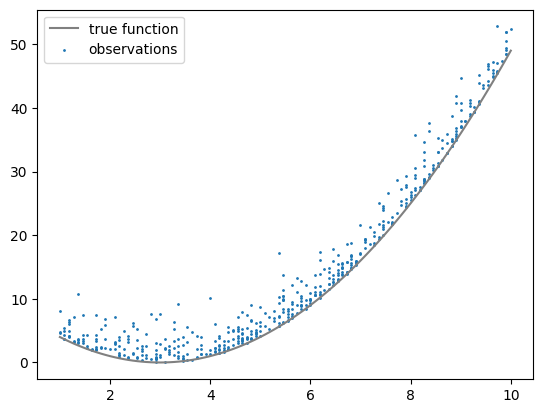

In [ ]:
def f_true(x):
    return (x - 3) ** 2

x = numpy.linspace(1, 10, 100)
x_observed = numpy.random.choice(x, size=500, replace=True)
y_observed = f_true(x_observed) + numpy.random.exponential(2.0, len(x_observed))

plt.plot(x, f_true(x), c="grey", label="true function")
plt.scatter(x_observed, y_observed, s=1.0, label="observations")
plt.legend()

In [3]:
import sklearn.preprocessing

def add_bias_to_features(X):
    return numpy.concatenate([ numpy.ones_like(X)[:, 0:1], X ], axis = -1)

pf = sklearn.preprocessing.PolynomialFeatures()

X_train = pf.fit_transform(add_bias_to_features(x_observed.reshape(-1, 1)))
y_train = y_observed

X_test = pf.transform(add_bias_to_features(x.reshape(-1, 1)))
y_test = f_true(x)

X_train.shape, y_train.shape, X_test.shape, y_test.shape

((500, 6), (500,), (100, 6), (100,))

Хотим:
- Модель (bias включён в X): $y = X w + \epsilon$, $\epsilon \sim Exp$
- $\epsilon \sim Exp \Rightarrow y \ge X w$

Эквивалентно: хотим максимизровать $X w$ (или минимизировать $- X w$) с условием $y \ge X w$. Это задача линейного программирования.

$$\min(- X w) \sim \min \sum_{i = 0}^{n} \left(- x_i w\right) = \min \left(- \sum_{i = 0}^{n} x_i\right) w$$

В терминах `scipy.optimize.linprog`,
- Хотим $\min_x c^T x $
    - $x := w^T$
    - $c := - \sum_{i = 0}^{n} x_i$
- С условием: $A_{ub} x \leq b_{ub}$
    - $A_{ub} := X$
    - $b_{ub} := y$

In [4]:
import scipy.optimize

result = scipy.optimize.linprog(
    -numpy.sum(X_train, axis = 0),
    A_ub = X_train,
    b_ub = y_train,
    bounds = [(None, None)] * X_train.shape[1] # No bounds
)
print(result)

w = result.x.T
print(w)

        message: Optimization terminated successfully. (HiGHS Status 7: Optimal)
        success: True
         status: 0
            fun: -6276.78766415254
              x: [ 0.000e+00  0.000e+00  0.000e+00  9.000e+00 -6.000e+00
                   1.000e+00]
            nit: 7
          lower:  residual: [       inf        inf        inf        inf
                                    inf        inf]
                 marginals: [ 0.000e+00  0.000e+00  0.000e+00  0.000e+00
                              0.000e+00  0.000e+00]
          upper:  residual: [       inf        inf        inf        inf
                                    inf        inf]
                 marginals: [ 0.000e+00  0.000e+00  0.000e+00  0.000e+00
                              0.000e+00  0.000e+00]
          eqlin:  residual: []
                 marginals: []
        ineqlin:  residual: [ 1.708e-01  5.442e-01 ...  2.706e+00
                              2.561e+00]
                 marginals: [-0.000e+00 -0.000e+00 .

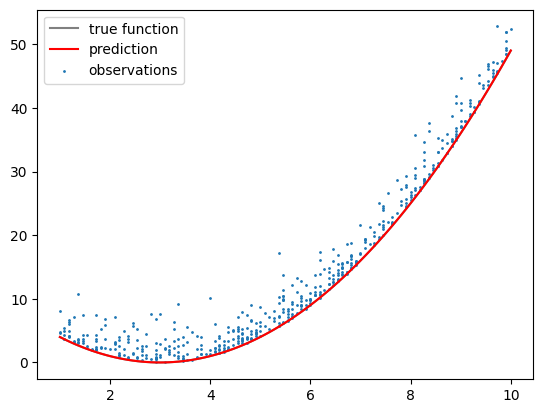

In [5]:
plt.plot(x, f_true(x), c="grey", label="true function")
plt.plot(x, X_test @ w, c = "red", label = "prediction")
plt.scatter(x_observed, y_observed, s=1.0, label="observations")
plt.legend()

## Задача со звездочкой 9: Эллипс

Вы оказались одни в лесу, и вам очень надо восстановить уравнение эллипса по данным. Как на зло, все что у вас есть - это `sklearn.linear_model.LinearRegression`.

**1 балл.** К счастью, вы знаете что эллипс не абы какой, а с осями, параллельными осям координат.

**1 балл.** А теперь не знаете. (WARNING: я не уверен в том, что это возможно c `LinearRegression`, но OLS может)

In [6]:
numpy.random.seed(42)

In [7]:
# Правильный ответ
CENTER_X = -5.0
CENTER_Y = 2.0
SCALE_X = 2.0
SCALE_Y = 3.0
ANGLE = numpy.pi / 6

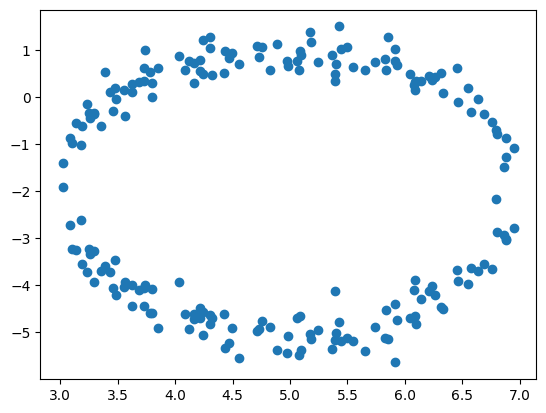

In [8]:
# Генерируем данные
x = numpy.random.rand(100) * 2 - 1
y_pos = numpy.sqrt(1 - x**2) + numpy.random.normal(0, 0.1, 100)
y_neg = -numpy.sqrt(1 - x**2) + numpy.random.normal(0, 0.1, 100)
y = numpy.hstack([y_pos, y_neg])
x = x * SCALE_X - CENTER_X
y = y * SCALE_Y - CENTER_Y
x = numpy.hstack([x, x])
data = numpy.stack([x, y], axis=1)
plt.scatter(data[:, 0], data[:, 1])

#### Оси, параллельные осям координат

Эллипс с осями, параллельными осям координат: $A x^2 + B y^2 + C x + D y + E = 0$

Тем не менее в таком виде предсказания будут $[ A, B, C, D, E ] = [ 0, 0, 0, 0, 0 ]$

Трансформируем уравнение: $\dfrac{A}{D} x^2 + \dfrac{B}{D} y^2 + \dfrac{C}{D} x + \dfrac{E}{D} = -y$

----

Получим уравнение заданного эллипса в таком виде для сравнения предсказаний.

$$ \dfrac{(x - 5)^2}{2^2} + \dfrac{(y + 2) ^ 2}{3^2} = 1 $$
$$ \dfrac{x^2 - 10x + 25}{4} + \dfrac{y^2 + 4y + 4}{9} = 1 $$
$$ \dfrac{1}{4} x^2 -\dfrac{10}{4} x + \dfrac{1}{9} y^2 + \dfrac{4}{9} y + \left(\dfrac{25}{4} + \dfrac{4}{9} - 1\right) = 0 $$
$$ \dfrac{9}{16} x^2 + \dfrac{1}{4} y^2 -\dfrac{45}{8} x + \dfrac{205}{16} = -y $$

In [9]:
target = numpy.array([ 9/16, 1/4, -45/8, 205/16 ])
target

array([ 0.5625,  0.25  , -5.625 , 12.8125])

In [10]:
import sklearn.linear_model

X = numpy.hstack([
    (data[:, 0] ** 2).reshape(-1, 1), # x^2,
    (data[:, 1] ** 2).reshape(-1, 1), # y^2,
    (data[:, 0]).reshape(-1, 1), # x
])
Y = -data[:, 1]

lr = sklearn.linear_model.LinearRegression()
lr.fit(X, Y)

pred = numpy.array([ *lr.coef_, lr.intercept_ ])
pred # В целом, похоже

array([ 0.54568881,  0.24080491, -5.4481113 , 12.44439143])

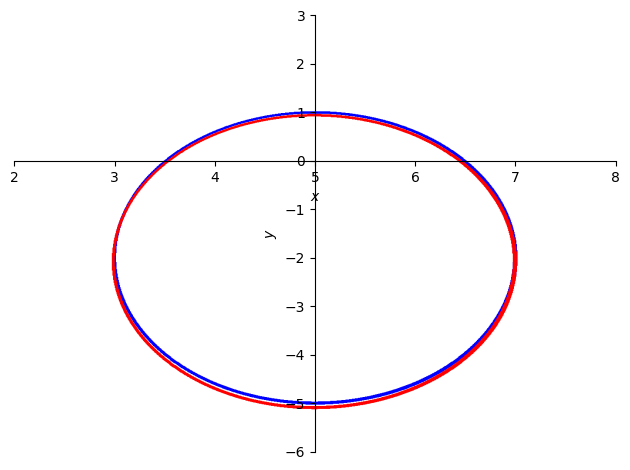

In [11]:
import sympy

s_x = sympy.Symbol('x', real = True)
s_y = sympy.Symbol('y', real = True)

target_eq = sympy.Eq(target @ [ s_x ** 2, s_y ** 2, s_x, 1 ], -s_y)
pred_eq = sympy.Eq(pred @ [ s_x ** 2, s_y ** 2, s_x, 1 ], -s_y)

plot = sympy.plot_implicit(target_eq, (s_x, 2, 8), (s_y, -6, 3), line_color = 'b', show = False)
plot.extend(sympy.plot_implicit(pred_eq, (s_x, 2, 8), (s_y, -6, 3), line_color = 'r', show = False))
plot.show() # Действительно похоже

#### Произвольные оси

Сначала подготовим данные - повернем исходный эллипс на заднный угол

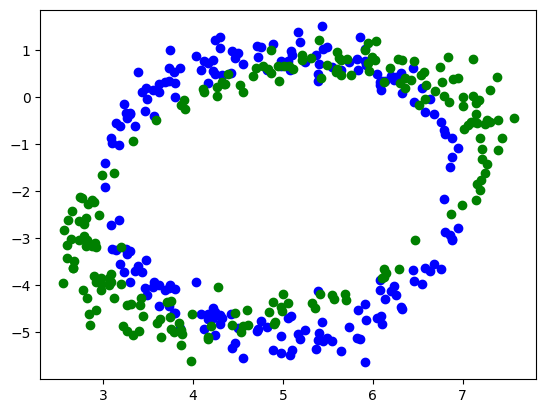

In [12]:
# Добавим третью координату из единиц для удобства
data_3d = numpy.hstack([ data, numpy.ones((len(data), 1)) ])

# Линейный оператор сдвига эллипса в начало координат
move_op = numpy.array([
    [ 1, 0, CENTER_X ],
    [ 0, 1, CENTER_Y ],
    [ 0, 0, 1 ]
])

# Линейный оператор поворота на заданный угол вокруг начала координат
rotate_op = numpy.array([
    [ numpy.cos(ANGLE), numpy.sin(ANGLE), 0],
    [ -numpy.sin(ANGLE), numpy.cos(ANGLE), 0],
    [ 0, 0, 1 ]
])

# Линейный оператор поворота эллипса вокруг центра эллипса:
# сдвинуть в начало координат, повернуть вокруг начала координат, вернуть на исходные координаты
transform_op = numpy.linalg.inv(move_op) @ rotate_op @ move_op

data_rotated = (transform_op @ data_3d.T).T[:, :2]

plt.scatter(data[:, 0], data[:, 1], c ='b')
plt.scatter(data_rotated[:, 0], data_rotated[:, 1], c ='g')

Уравнение произвольного эллипса: $A x^2 + B y^2 + C x y + D x + E y + F = 0$

Аналогично предыдущей части, предсказывать будем таким образом: $\dfrac{A}{E} x^2 + \dfrac{B}{E} y^2 + \dfrac{C}{E} x y + \dfrac{D}{E} x + \dfrac{F}{E} = -y$

---

"Правильный ответ" (уравнение заданного эллипса, повернутого на указанный угол), получим заменой координат в уравнении эллипса без поворота.

In [13]:
# Уравнение эллипса с осями, параллельными осям координат
target_eq

Eq(0.5625*x**2 - 5.625*x + 0.25*y**2 + 12.8125, -y)

In [14]:
# Замена координат
new_coords = numpy.linalg.inv(transform_op) @ [ s_x, s_y, 1 ]
coord_replacement = { s_x: new_coords[0], s_y: new_coords[1] }
coord_replacement

{x: 0.866025403784439*x - 0.5*y - 0.330127018922193,
 y: 0.5*x + 0.866025403784439*y - 2.76794919243112}

In [15]:
# Уравнение повернутого эллипса
target_eq_rotated = target_eq.subs(coord_replacement, simultaneous = True)
target_eq_rotated

Eq(-4.87139289628747*x + 2.8125*y + 0.25*(0.5*x + 0.866025403784439*y - 2.76794919243112)**2 + 0.5625*(0.866025403784439*x - 0.5*y - 0.330127018922193)**2 + 14.6694644814373, -0.5*x - 0.866025403784439*y + 2.76794919243112)

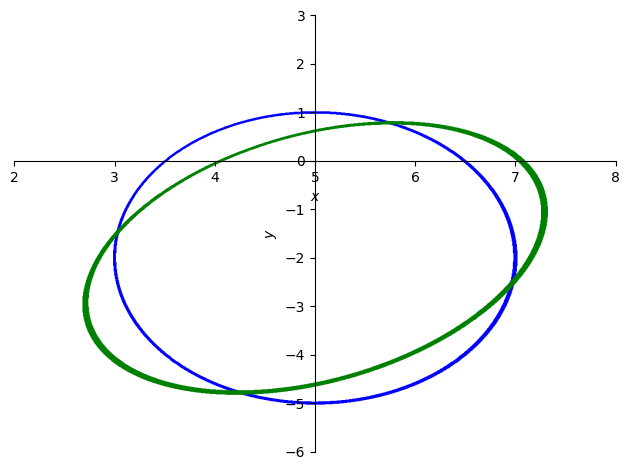

In [16]:
plot = sympy.plot_implicit(target_eq, (s_x, 2, 8), (s_y, -6, 3), line_color = 'b', show = False)
plot.extend(sympy.plot_implicit(target_eq_rotated, (s_x, 2, 8), (s_y, -6, 3), line_color = 'g', show = False))
plot.show()

In [17]:
import sklearn.linear_model

X = numpy.hstack([
    (data_rotated[:, 0] ** 2).reshape(-1, 1), # x^2,
    (data_rotated[:, 1] ** 2).reshape(-1, 1), # y^2,
    (data_rotated[:, 0] * data_rotated[:, 1]).reshape(-1, 1), # xy,
    (data_rotated[:, 0]).reshape(-1, 1), # x
])
Y = -data_rotated[:, 1]

lr_rotated = sklearn.linear_model.LinearRegression()
lr_rotated.fit(X, Y)

pred_rotated = numpy.array([ *lr_rotated.coef_, lr_rotated.intercept_ ])
pred_rotated

array([ 0.16238714,  0.10175988, -0.11804195, -1.85453598,  4.95716719])

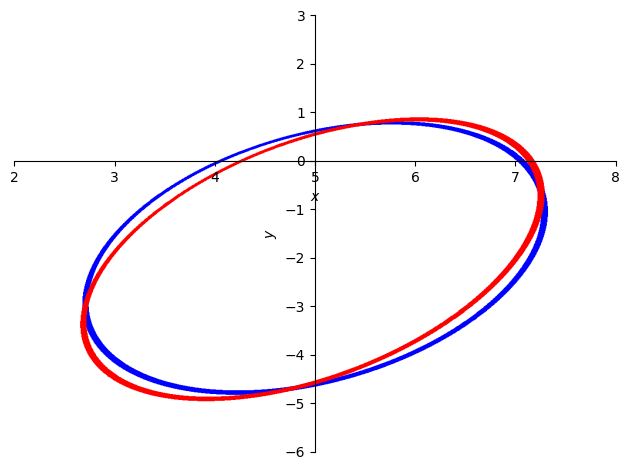

In [18]:
pred_eq_rotated = sympy.Eq(pred_rotated @ [ s_x ** 2, s_y ** 2, s_x * s_y, s_x, 1 ], -s_y)

plot = sympy.plot_implicit(target_eq_rotated, (s_x, 2, 8), (s_y, -6, 3), line_color = 'b', show = False)
plot.extend(sympy.plot_implicit(pred_eq_rotated, (s_x, 2, 8), (s_y, -6, 3), line_color = 'r', show = False))
plot.show() # Похоже

## Задача со звездочкой 10. Happiness (3 балла)
Возьмите большой социологический датасет (например, World Value Survey) и узнайте, наконец, что делает людей счастливыми. Дизайн исследования на ваше усмотрение.

Оценка ставится, если вы присылаете читаемый и прокомментированный ноутбук, в котором отсутствуют ошибки дизайна исслледований, о которых мы говорили сегодня. Еще, мне будет гораздо приятнее проверять работы, в которых у вас получается выудить какой-то нетривиальный паттерн в этих данных, а не "инсоляция и доход повышают expexted happiness, a войны -- понижают".

In [19]:
numpy.random.seed(42)

In [20]:
# Список признаков из Codebook
features = [
    {
        'name': 'cntry',
        'description': 'Country',
        'missing': []
    },
    {
        'name': 'nwspol',
        'description': 'News about politics and current affairs, watching, reading or listening, in minutes',
        'missing': [7777, 8888, 9999]
    },
    {
        'name': 'netusoft',
        'description': 'Internet use, how often',
        'missing': [7, 8, 9]
    },
    {
        'name': 'netustm',
        'description': 'Internet use, how much time on typical day, in minutes',
        'missing': [6666, 7777, 8888, 9999]
    },
    {
        'name': 'ppltrst',
        'description': 'Most people can be trusted or you can\'t be too careful',
        'missing': [77, 88, 99]
    },
    {
        'name': 'pplfair',
        'description': 'Most people try to take advantage of you, or try to be fair',
        'missing': [77, 88, 99]
    },
    {
        'name': 'pplhlp',
        'description': 'Most of the time people helpful or mostly looking out for themselves',
        'missing': [77, 88, 99]
    },
    {
        'name': 'polintr',
        'description': 'How interested in politics',
        'missing': [7, 8, 9]
    },
    {
        'name': 'psppsgva',
        'description': 'Political system allows people to have a say in what government does',
        'missing': [7, 8, 9]
    },
    {
        'name': 'actrolga',
        'description': 'Able to take active role in political group',
        'missing': [7, 8, 9]
    },
    {
        'name': 'psppipla',
        'description': 'Political system allows people to have influence on politics',
        'missing': [7, 8, 9]
    },
    {
        'name': 'cptppola',
        'description': 'Confident in own ability to participate in politics',
        'missing': [7, 8, 9]
    },
    {
        'name': 'trstprl',
        'description': 'Trust in country\'s parliament',
        'missing': [77, 88, 99]
    },
    {
        'name': 'trstlgl',
        'description': 'Trust in the legal system',
        'missing': [77, 88, 99]
    },
    {
        'name': 'trstplc',
        'description': 'Trust in the police',
        'missing': [77, 88, 99]
    },
    {
        'name': 'trstplt',
        'description': 'Trust in politicians',
        'missing': [77, 88, 99]
    },
    {
        'name': 'trstprt',
        'description': 'Trust in political parties',
        'missing': [77, 88, 99]
    },
    {
        'name': 'trstep',
        'description': 'Trust in the European Parliament',
        'missing': [77, 88, 99]
    },
    {
        'name': 'trstun',
        'description': 'Trust in the United Nations',
        'missing': [77, 88, 99]
    },
    {
        'name': 'vote',
        'description': 'Voted last national election',
        'missing': [7, 8, 9]
    },
    {
        'name': 'prtvtdat',
        'description': 'Party voted for in last national election, Austria',
        'missing': [66, 77, 88, 99]
    },
    {
        'name': 'prtvtebe',
        'description': 'Party voted for in last national election, Belgium',
        'missing': [66, 77, 88, 99]
    },
    {
        'name': 'prtvtfbg',
        'description': 'Party voted for in last national election, Bulgaria',
        'missing': [66, 77, 88, 99]
    },
    {
        'name': 'prtvtchr',
        'description': 'Party voted for in last national election, Croatia',
        'missing': [66, 77, 88, 99]
    },
    {
        'name': 'prtvtccy',
        'description': 'Party voted for in last national election, Cyprus',
        'missing': [66, 77, 88, 99]
    },
    {
        'name': 'prtvtiee',
        'description': 'Party voted for in last national election, Estonia',
        'missing': [66, 77, 88, 99]
    },
    {
        'name': 'prtvtffi',
        'description': 'Party voted for in last national election, Finland',
        'missing': [66, 77, 88, 99]
    },
    {
        'name': 'prtvtffr',
        'description': 'Party voted for in last national election, France (ballot 1)',
        'missing': [66, 77, 88, 99]
    },
    {
        'name': 'prtvgde1',
        'description': 'Party voted for in last national election 1, Germany',
        'missing': [66, 77, 88, 99]
    },
    {
        'name': 'prtvgde2',
        'description': 'Party voted for in last national election 2, Germany',
        'missing': [66, 77, 88, 99]
    },
    {
        'name': 'prtvtegr',
        'description': 'Party voted for in last national election, Greece',
        'missing': [66, 77, 88, 99]
    },
    {
        'name': 'prtvthhu',
        'description': 'Party voted for in last national election, Hungary',
        'missing': [66, 77, 88, 99]
    },
    {
        'name': 'prtvteis',
        'description': 'Party voted for in last national election, Iceland',
        'missing': [66, 77, 88, 99]
    },
    {
        'name': 'prtvteie',
        'description': 'Party voted for in last national election, Ireland (derived from 1st preference vote)',
        'missing': [66, 77, 88, 99]
    },
    {
        'name': 'prtvteil',
        'description': 'Party voted for in last national election, Israel',
        'missing': [66, 77, 88, 99]
    },
    {
        'name': 'prtvteit',
        'description': 'Party voted for in last national election, Italy',
        'missing': [66, 77, 88, 99]
    },
    {
        'name': 'prtvtblv',
        'description': 'Party voted for in last national election, Latvia',
        'missing': [66, 77, 88, 99]
    },
    {
        'name': 'prtvclt1',
        'description': 'Party voted for in last national election 1, Lithuania (first vote, party)',
        'missing': [66, 77, 88, 99]
    },
    {
        'name': 'prtvclt2',
        'description': 'Party voted for in last national election 2, Lithuania (second vote, party)',
        'missing': [66, 77, 88, 99]
    },
    {
        'name': 'prtvclt3',
        'description': 'Party voted for in last national election 3, Lithuania (third vote, party)',
        'missing': [66, 77, 88, 99]
    },
    {
        'name': 'prtvtbme',
        'description': 'Party voted for in last national election, Montenegro',
        'missing': [66, 77, 88, 99]
    },
    {
        'name': 'prtvtinl',
        'description': 'Party voted for in last national election, Netherlands',
        'missing': [66, 77, 88, 99]
    },
    {
        'name': 'prtvtcno',
        'description': 'Party voted for in last national election, Norway',
        'missing': [66, 77, 88, 99]
    },
    {
        'name': 'prtvtfpl',
        'description': 'Party voted for in last national election, Poland',
        'missing': [66, 77, 88, 99]
    },
    {
        'name': 'prtvtept',
        'description': 'Party voted for in last national election, Portugal',
        'missing': [66, 77, 88, 99]
    },
    {
        'name': 'prtvtbrs',
        'description': 'Party voted for in last national election, Serbia',
        'missing': [66, 77, 88, 99]
    },
    {
        'name': 'prtvtesk',
        'description': 'Party voted for in last national election, Slovakia',
        'missing': [66, 77, 88, 99]
    },
    {
        'name': 'prtvtgsi',
        'description': 'Party voted for in last national election, Slovenia',
        'missing': [66, 77, 88, 99]
    },
    {
        'name': 'prtvtges',
        'description': 'Party voted for in last national election, Spain',
        'missing': [66, 77, 88, 99]
    },
    {
        'name': 'prtvtdse',
        'description': 'Party voted for in last national election, Sweden',
        'missing': [66, 77, 88, 99]
    },
    {
        'name': 'prtvthch',
        'description': 'Party voted for in last national election, Switzerland',
        'missing': [66, 77, 88, 99]
    },
    {
        'name': 'prtvtdua',
        'description': 'Party voted for in last national election, Ukraine (ballot 2)',
        'missing': [66, 77, 88, 99]
    },
    {
        'name': 'prtvtdgb',
        'description': 'Party voted for in last national election, United Kingdom',
        'missing': [66, 77, 88, 99]
    },
    {
        'name': 'contplt',
        'description': 'Contacted politician or government official last 12 months',
        'missing': [7, 8, 9]
    },
    {
        'name': 'donprty',
        'description': 'Donated to or participated in political party or pressure group last 12 months',
        'missing': [7, 8, 9]
    },
    {
        'name': 'badge',
        'description': 'Worn or displayed campaign badge/sticker last 12 months',
        'missing': [7, 8, 9]
    },
    {
        'name': 'sgnptit',
        'description': 'Signed petition last 12 months',
        'missing': [7, 8, 9]
    },
    {
        'name': 'pbldmna',
        'description': 'Taken part in public demonstration last 12 months',
        'missing': [7, 8, 9]
    },
    {
        'name': 'bctprd',
        'description': 'Boycotted certain products last 12 months',
        'missing': [7, 8, 9]
    },
    {
        'name': 'pstplonl',
        'description': 'Posted or shared anything about politics online last 12 months',
        'missing': [7, 8, 9]
    },
    {
        'name': 'volunfp',
        'description': 'Volunteered for not-for-profit or charitable organisation',
        'missing': [7, 8, 9]
    },
    {
        'name': 'clsprty',
        'description': 'Feel closer to a particular party than all other parties',
        'missing': [7, 8, 9]
    },
    {
        'name': 'prtcleat',
        'description': 'Which party feel closer to, Austria',
        'missing': [66, 77, 88, 99]
    },
    {
        'name': 'prtclebe',
        'description': 'Which party feel closer to, Belgium',
        'missing': [66, 77, 88, 99]
    },
    {
        'name': 'prtclfbg',
        'description': 'Which party feel closer to, Bulgaria',
        'missing': [66, 77, 88, 99]
    },
    {
        'name': 'prtclbhr',
        'description': 'Which party feel closer to, Croatia',
        'missing': [66, 77, 88, 99]
    },
    {
        'name': 'prtclccy',
        'description': 'Which party feel closer to, Cyprus',
        'missing': [66, 77, 88, 99]
    },
    {
        'name': 'prtcliee',
        'description': 'Which party feel closer to, Estonia',
        'missing': [66, 77, 88, 99]
    },
    {
        'name': 'prtclgfi',
        'description': 'Which party feel closer to, Finland',
        'missing': [66, 77, 88, 99]
    },
    {
        'name': 'prtclgfr',
        'description': 'Which party feel closer to, France',
        'missing': [66, 77, 88, 99]
    },
    {
        'name': 'prtclgde',
        'description': 'Which party feel closer to, Germany',
        'missing': [66, 77, 88, 99]
    },
    {
        'name': 'prtclegr',
        'description': 'Which party feel closer to, Greece',
        'missing': [66, 77, 88, 99]
    },
    {
        'name': 'prtclihu',
        'description': 'Which party feel closer to, Hungary',
        'missing': [66, 77, 88, 99]
    },
    {
        'name': 'prtcleis',
        'description': 'Which party feel closer to, Iceland',
        'missing': [66, 77, 88, 99]
    },
    {
        'name': 'prtclfie',
        'description': 'Which party feel closer to, Ireland',
        'missing': [66, 77, 88, 99]
    },
    {
        'name': 'prtclfil',
        'description': 'Which party feel closer to, Israel',
        'missing': [66, 77, 88, 99]
    },
    {
        'name': 'prtclfit',
        'description': 'Which party feel closer to, Italy',
        'missing': [66, 77, 88, 99]
    },
    {
        'name': 'prtclblv',
        'description': 'Which party feel closer to, Latvia',
        'missing': [66, 77, 88, 99]
    },
    {
        'name': 'prtclclt',
        'description': 'Which party feel closer to, Lithuania',
        'missing': [66, 77, 88, 99]
    },
    {
        'name': 'prtclbme',
        'description': 'Which party feel closer to, Montenegro',
        'missing': [66, 77, 88, 99]
    },
    {
        'name': 'prtclhnl',
        'description': 'Which party feel closer to, Netherlands',
        'missing': [66, 77, 88, 99]
    },
    {
        'name': 'prtclcno',
        'description': 'Which party feel closer to, Norway',
        'missing': [66, 77, 88, 99]
    },
    {
        'name': 'prtcljpl',
        'description': 'Which party feel closer to, Poland',
        'missing': [66, 77, 88, 99]
    },
    {
        'name': 'prtclgpt',
        'description': 'Which party feel closer to, Portugal',
        'missing': [66, 77, 88, 99]
    },
    {
        'name': 'prtclbrs',
        'description': 'Which party feel closer to, Serbia',
        'missing': [66, 77, 88, 99]
    },
    {
        'name': 'prtclesk',
        'description': 'Which party feel closer to, Slovakia',
        'missing': [66, 77, 88, 99]
    },
    {
        'name': 'prtclgsi',
        'description': 'Which party feel closer to, Slovenia',
        'missing': [66, 77, 88, 99]
    },
    {
        'name': 'prtclhes',
        'description': 'Which party feel closer to, Spain',
        'missing': [66, 77, 88, 99]
    },
    {
        'name': 'prtcldse',
        'description': 'Which party feel closer to, Sweden',
        'missing': [66, 77, 88, 99]
    },
    {
        'name': 'prtclhch',
        'description': 'Which party feel closer to, Switzerland',
        'missing': [66, 77, 88, 99]
    },
    {
        'name': 'prtcleua',
        'description': 'Which party feel closer to, Ukraine',
        'missing': [66, 77, 88, 99]
    },
    {
        'name': 'prtcldgb',
        'description': 'Which party feel closer to, United Kingdom',
        'missing': [66, 77, 88, 99]
    },
    {
        'name': 'prtdgcl',
        'description': 'How close to party',
        'missing': [6, 7, 8, 9]
    },
    {
        'name': 'lrscale',
        'description': 'Placement on left right scale',
        'missing': [77, 88, 99]
    },
    {
        'name': 'stflife',
        'description': 'How satisfied with life as a whole',
        'missing': [77, 88, 99]
    },
    {
        'name': 'stfeco',
        'description': 'How satisfied with present state of economy in country',
        'missing': [77, 88, 99]
    },
    {
        'name': 'stfgov',
        'description': 'How satisfied with the national government',
        'missing': [77, 88, 99]
    },
    {
        'name': 'stfdem',
        'description': 'How satisfied with the way democracy works in country',
        'missing': [77, 88, 99]
    },
    {
        'name': 'stfedu',
        'description': 'State of education in country nowadays',
        'missing': [77, 88, 99]
    },
    {
        'name': 'stfhlth',
        'description': 'State of health services in country nowadays',
        'missing': [77, 88, 99]
    },
    {
        'name': 'gincdif',
        'description': 'Government should reduce differences in income levels',
        'missing': [7, 8, 9]
    },
    {
        'name': 'freehms',
        'description': 'Gays and lesbians free to live life as they wish',
        'missing': [7, 8, 9]
    },
    {
        'name': 'hmsfmlsh',
        'description': 'Ashamed if close family member gay or lesbian',
        'missing': [7, 8, 9]
    },
    {
        'name': 'hmsacld',
        'description': 'Gay and lesbian couples right to adopt children',
        'missing': [7, 8, 9]
    },
    {
        'name': 'euftf',
        'description': 'European Union: European unification go further or gone too far',
        'missing': [77, 88, 99]
    },
    {
        'name': 'lrnobed',
        'description': 'Obedience and respect for authority most important virtues children should learn',
        'missing': [7, 8, 9]
    },
    {
        'name': 'loylead',
        'description': 'Country needs most loyalty towards its leaders',
        'missing': [7, 8, 9]
    },
    {
        'name': 'imsmetn',
        'description': 'Allow many/few immigrants of same race/ethnic group as majority',
        'missing': [7, 8, 9]
    },
    {
        'name': 'imdfetn',
        'description': 'Allow many/few immigrants of different race/ethnic group from majority',
        'missing': [7, 8, 9]
    },
    {
        'name': 'impcntr',
        'description': 'Allow many/few immigrants from poorer countries outside Europe',
        'missing': [7, 8, 9]
    },
    {
        'name': 'imbgeco',
        'description': 'Immigration bad or good for country\'s economy',
        'missing': [77, 88, 99]
    },
    {
        'name': 'imueclt',
        'description': 'Country\'s cultural life undermined or enriched by immigrants',
        'missing': [77, 88, 99]
    },
    {
        'name': 'imwbcnt',
        'description': 'Immigrants make country worse or better place to live',
        'missing': [77, 88, 99]
    },
    {
        'name': 'happy',
        'description': 'How happy are you',
        'missing': [77, 88, 99]
    },
    {
        'name': 'sclmeet',
        'description': 'How often socially meet with friends, relatives or colleagues',
        'missing': [77, 88, 99]
    },
    {
        'name': 'inprdsc',
        'description': 'How many people with whom you can discuss intimate and personal matters',
        'missing': [77, 88, 99]
    },
    {
        'name': 'sclact',
        'description': 'Take part in social activities compared to others of same age',
        'missing': [7, 8, 9]
    },
    {
        'name': 'crmvct',
        'description': 'Respondent or household member victim of burglary/assault last 5 years',
        'missing': [7, 8, 9]
    },
    {
        'name': 'aesfdrk',
        'description': 'Feeling of safety of walking alone in local area after dark',
        'missing': [7, 8, 9]
    },
    {
        'name': 'health',
        'description': 'Subjective general health',
        'missing': [7, 8, 9]
    },
    {
        'name': 'hlthhmp',
        'description': 'Hampered in daily activities by illness/disability/infirmity/mental problem',
        'missing': [7, 8, 9]
    },
    {
        'name': 'atchctr',
        'description': 'How emotionally attached to [country]',
        'missing': [77, 88, 99]
    },
    {
        'name': 'atcherp',
        'description': 'How emotionally attached to Europe',
        'missing': [77, 88, 99]
    },
    {
        'name': 'rlgblg',
        'description': 'Belonging to particular religion or denomination',
        'missing': [7, 8, 9]
    },
    {
        'name': 'rlgdnm',
        'description': 'Religion or denomination belonging to at present',
        'missing': [66, 77, 99]
    },
    {
        'name': 'rlgdnbat',
        'description': 'Religion or denomination belonging to at present, Austria',
        'missing': [6666, 7777, 9999]
    },
    {
        'name': 'rlgdnacy',
        'description': 'Religion or denomination belonging to at present, Cyprus',
        'missing': [6666, 7777, 9999]
    },
    {
        'name': 'rlgdnafi',
        'description': 'Religion or denomination belonging to at present, Finland',
        'missing': [6666, 7777, 9999]
    },
    {
        'name': 'rlgdnade',
        'description': 'Religion or denomination belonging to at present, Germany',
        'missing': [6666, 7777, 9999]
    },
    {
        'name': 'rlgdnagr',
        'description': 'Religion or denomination belonging to at present, Greece',
        'missing': [6666, 7777, 9999]
    },
    {
        'name': 'rlgdnhu',
        'description': 'Religion or denomination belonging to at present, Hungary',
        'missing': [6666, 7777, 9999]
    },
    {
        'name': 'rlgdnais',
        'description': 'Religion or denomination belonging to at present, Iceland',
        'missing': [6666, 7777, 9999]
    },
    {
        'name': 'rlgdnie',
        'description': 'Religion or denomination belonging to at present, Ireland',
        'missing': [6666, 7777, 9999]
    },
    {
        'name': 'rlgdnlv',
        'description': 'Religion or denomination belonging to at present, Latvia',
        'missing': [6666, 7777, 9999]
    },
    {
        'name': 'rlgdnlt',
        'description': 'Religion or denomination belonging to at present, Lithuania',
        'missing': [6666, 7777, 9999]
    },
    {
        'name': 'rlgdme',
        'description': 'Religion or denomination belonging to at present, Montenegro',
        'missing': [6666, 7777, 9999]
    },
    {
        'name': 'rlgdnanl',
        'description': 'Religion or denomination belonging to at present, Netherlands',
        'missing': [6666, 7777, 9999]
    },
    {
        'name': 'rlgdnno',
        'description': 'Religion or denomination belonging to at present, Norway',
        'missing': [6666, 7777, 9999]
    },
    {
        'name': 'rlgdnapl',
        'description': 'Religion or denomination belonging to at present, Poland',
        'missing': [6666, 7777, 9999]
    },
    {
        'name': 'rlgdnapt',
        'description': 'Religion or denomination belonging to at present, Portugal',
        'missing': [6666, 7777, 9999]
    },
    {
        'name': 'rlgdnrs',
        'description': 'Religion or denomination belonging to at present, Serbia',
        'missing': [6666, 7777, 9999]
    },
    {
        'name': 'rlgdnask',
        'description': 'Religion or denomination belonging to at present, Slovakia',
        'missing': [6666, 7777, 9999]
    },
    {
        'name': 'rlgdnase',
        'description': 'Religion or denomination belonging to at present, Sweden',
        'missing': [6666, 7777, 9999]
    },
    {
        'name': 'rlgdnach',
        'description': 'Religion or denomination belonging to at present, Switzerland',
        'missing': [6666, 7777, 9999]
    },
    {
        'name': 'rlgdnaua',
        'description': 'Religion or denomination belonging to at present, Ukraine',
        'missing': [6666, 7777, 9999]
    },
    {
        'name': 'rlgdngb',
        'description': 'Religion or denomination belonging to at present, United Kingdom',
        'missing': [6666, 7777, 9999]
    },
    {
        'name': 'rlgblge',
        'description': 'Ever belonging to particular religion or denomination',
        'missing': [6, 7, 8, 9]
    },
    {
        'name': 'rlgdnme',
        'description': 'Religion or denomination belonging to in the past',
        'missing': [66, 77, 99]
    },
    {
        'name': 'rlgdebat',
        'description': 'Religion or denomination belonging to in the past, Austria',
        'missing': [6666, 7777, 9999]
    },
    {
        'name': 'rlgdeacy',
        'description': 'Religion or denomination belonging to in the past, Cyprus',
        'missing': [6666, 7777, 9999]
    },
    {
        'name': 'rlgdeafi',
        'description': 'Religion or denomination belonging to in the past, Finland',
        'missing': [6666, 7777, 9999]
    },
    {
        'name': 'rlgdeade',
        'description': 'Religion or denomination belonging to in the past, Germany',
        'missing': [6666, 7777, 9999]
    },
    {
        'name': 'rlgdeagr',
        'description': 'Religion or denomination belonging to in the past, Greece',
        'missing': [6666, 7777, 9999]
    },
    {
        'name': 'rlgdehu',
        'description': 'Religion or denomination belonging to in the past, Hungary',
        'missing': [6666, 7777, 9999]
    },
    {
        'name': 'rlgdeais',
        'description': 'Religion or denomination belonging to in the past, Iceland',
        'missing': [6666, 7777, 9999]
    },
    {
        'name': 'rlgdeie',
        'description': 'Religion or denomination belonging to in the past, Ireland',
        'missing': [6666, 7777, 9999]
    },
    {
        'name': 'rlgdelv',
        'description': 'Religion or denomination belonging to in the past, Latvia',
        'missing': [6666, 7777, 9999]
    },
    {
        'name': 'rlgdelt',
        'description': 'Religion or denomination belonging to in the past, Lithuania',
        'missing': [6666, 7777, 9999]
    },
    {
        'name': 'rlgdeme',
        'description': 'Religion or denomination belonging to in the past, Montenegro',
        'missing': [6666, 7777, 9999]
    },
    {
        'name': 'rlgdeanl',
        'description': 'Religion or denomination belonging to in the past, Netherlands',
        'missing': [6666, 7777, 9999]
    },
    {
        'name': 'rlgdeno',
        'description': 'Religion or denomination belonging to in the past, Norway',
        'missing': [6666, 7777, 9999]
    },
    {
        'name': 'rlgdeapl',
        'description': 'Religion or denomination belonging to in the past, Poland',
        'missing': [6666, 7777, 9999]
    },
    {
        'name': 'rlgdeapt',
        'description': 'Religion or denomination belonging to in the past, Portugal',
        'missing': [6666, 7777, 9999]
    },
    {
        'name': 'rlgders',
        'description': 'Religion or denomination belonging to in the past, Serbia',
        'missing': [6666, 7777, 9999]
    },
    {
        'name': 'rlgdeask',
        'description': 'Religion or denomination belonging to in the past, Slovakia',
        'missing': [6666, 7777, 9999]
    },
    {
        'name': 'rlgdease',
        'description': 'Religion or denomination belonging to in the past, Sweden',
        'missing': [6666, 7777, 9999]
    },
    {
        'name': 'rlgdeach',
        'description': 'Religion or denomination belonging to in the past, Switzerland',
        'missing': [6666, 7777, 9999]
    },
    {
        'name': 'rlgdeaua',
        'description': 'Religion or denomination belonging to in the past, Ukraine',
        'missing': [6666, 7777, 9999]
    },
    {
        'name': 'rlgdegb',
        'description': 'Religion or denomination belonging to in the past, United Kingdom',
        'missing': [6666, 7777, 9999]
    },
    {
        'name': 'rlgdgr',
        'description': 'How religious are you',
        'missing': [77, 88, 99]
    },
    {
        'name': 'rlgatnd',
        'description': 'How often attend religious services apart from special occasions',
        'missing': [77, 88, 99]
    },
    {
        'name': 'pray',
        'description': 'How often pray apart from at religious services',
        'missing': [77, 88, 99]
    },
    {
        'name': 'dscrgrp',
        'description': 'Member of a group discriminated against in this country',
        'missing': [7, 8, 9]
    },
    {
        'name': 'dscrrce',
        'description': 'Discrimination of respondent\'s group: colour or race',
        'missing': []
    },
    {
        'name': 'dscrntn',
        'description': 'Discrimination of respondent\'s group: nationality',
        'missing': []
    },
    {
        'name': 'dscrrlg',
        'description': 'Discrimination of respondent\'s group: religion',
        'missing': []
    },
    {
        'name': 'dscrlng',
        'description': 'Discrimination of respondent\'s group: language',
        'missing': []
    },
    {
        'name': 'dscretn',
        'description': 'Discrimination of respondent\'s group: ethnic group',
        'missing': []
    },
    {
        'name': 'dscrage',
        'description': 'Discrimination of respondent\'s group: age',
        'missing': []
    },
    {
        'name': 'dscrgnd',
        'description': 'Discrimination of respondent\'s group: gender',
        'missing': []
    },
    {
        'name': 'dscrsex',
        'description': 'Discrimination of respondent\'s group: sexuality',
        'missing': []
    },
    {
        'name': 'dscrdsb',
        'description': 'Discrimination of respondent\'s group: disability',
        'missing': []
    },
    {
        'name': 'ctzcntr',
        'description': 'Citizen of country',
        'missing': [7, 8, 9]
    },
    {
        'name': 'brncntr',
        'description': 'Born in country',
        'missing': [7, 8, 9]
    },
    {
        'name': 'cntbrthd',
        'description': 'Country of birth',
        'missing': [6666, 7777, 8888, 9999]
    },
    {
        'name': 'livecnta',
        'description': 'What year you first came to live in country',
        'missing': [6666, 7777, 8888, 9999]
    },
    {
        'name': 'feethngr',
        'description': 'Feel part of same race or ethnic group as most people in country',
        'missing': [7, 8, 9]
    },
    {
        'name': 'facntr',
        'description': 'Father born in country',
        'missing': [7, 8, 9]
    },
    {
        'name': 'fbrncntc',
        'description': 'Country of birth, father',
        'missing': [6666, 7777, 8888, 9999]
    },
    {
        'name': 'mocntr',
        'description': 'Mother born in country',
        'missing': [7, 8, 9]
    },
    {
        'name': 'mbrncntc',
        'description': 'Country of birth, mother',
        'missing': [6666, 7777, 8888, 9999]
    },
    {
        'name': 'ccnthum',
        'description': 'Climate change caused by natural processes, human activity, or both',
        'missing': [77, 88, 99]
    },
    {
        'name': 'ccrdprs',
        'description': 'To what extent feel personal responsibility to reduce climate change',
        'missing': [66, 77, 88, 99]
    },
    {
        'name': 'wrclmch',
        'description': 'How worried about climate change',
        'missing': [6, 7, 8, 9]
    },
    {
        'name': 'admrclc',
        'description': 'Administration of reduce climate change',
        'missing': [6, 9]
    },
    {
        'name': 'testjc34',
        'description': 'Imagine large numbers of people limit energy use, how likely reduce climate change',
        'missing': [66, 77, 88, 99]
    },
    {
        'name': 'testjc35',
        'description': 'How likely, large numbers of people limit energy use',
        'missing': [66, 77, 88, 99]
    },
    {
        'name': 'testjc36',
        'description': 'How likely, governments in enough countries take action to reduce climate change',
        'missing': [66, 77, 88, 99]
    },
    {
        'name': 'testjc37',
        'description': 'Imagine large numbers of people limit energy use, how likely reduce climate change',
        'missing': [6, 7, 8, 9]
    },
    {
        'name': 'testjc38',
        'description': 'How likely, large numbers of  people limit energy use',
        'missing': [6, 7, 8, 9]
    },
    {
        'name': 'testjc39',
        'description': 'How likely, governments in enough countries take action to reduce climate change',
        'missing': [6, 7, 8, 9]
    },
    {
        'name': 'testjc40',
        'description': 'Imagine large numbers of people limit energy use, how likely reduce climate change',
        'missing': [6, 7, 8, 9]
    },
    {
        'name': 'testjc41',
        'description': 'How likely, large numbers of people limit energy use',
        'missing': [6, 7, 8, 9]
    },
    {
        'name': 'testjc42',
        'description': 'How likely, governments in enough countries take action to reduce climate change',
        'missing': [6, 7, 8, 9]
    },
    {
        'name': 'vteurmmb',
        'description': 'Would vote for [country] to remain member of European Union or leave',
        'missing': [77, 88, 99]
    },
    {
        'name': 'vteubcmb',
        'description': 'Would vote for [country] to become member of European Union or remain outside',
        'missing': [77, 88, 99]
    },
    {
        'name': 'ctrlife',
        'description': 'How much control over life in general nowadays',
        'missing': [77, 88, 99]
    },
    {
        'name': 'etfruit',
        'description': 'How often eat fruit, excluding drinking juice',
        'missing': [77, 88, 99]
    },
    {
        'name': 'eatveg',
        'description': 'How often eat vegetables or salad, excluding potatoes',
        'missing': [77, 88, 99]
    },
    {
        'name': 'dosprt',
        'description': 'Do sports or other physical activity, how many of last 7 days',
        'missing': [77, 88, 99]
    },
    {
        'name': 'cgtsmok',
        'description': 'Cigarette smoking behaviour',
        'missing': [7, 8, 9]
    },
    {
        'name': 'alcfreq',
        'description': 'How often drink alcohol',
        'missing': [77, 88, 99]
    },
    {
        'name': 'alcwkdy',
        'description': 'Grams alcohol, last time drinking on a weekday, Monday to Thursday',
        'missing': [6666, 7777, 8888, 9999]
    },
    {
        'name': 'alcwknd',
        'description': 'Grams alcohol, last time drinking on a weekend day, Friday to Sunday',
        'missing': [6666, 7777, 8888, 9999]
    },
    {
        'name': 'icgndra',
        'description': 'Interviewer code, gender of respondent',
        'missing': [6, 9]
    },
    {
        'name': 'alcbnge',
        'description': 'Frequency of binge drinking for men and women, last 12 months',
        'missing': [6, 7, 8, 9]
    },
    {
        'name': 'height',
        'description': 'Height of respondent (cm)',
        'missing': [777, 888, 999]
    },
    {
        'name': 'weighta',
        'description': 'Weight of respondent (kg)',
        'missing': [777, 888, 999]
    },
    {
        'name': 'dshltgp',
        'description': 'Discussed health, last 12 months: general practitioner',
        'missing': []
    },
    {
        'name': 'dshltms',
        'description': 'Discussed health, last 12 months: medical specialist',
        'missing': []
    },
    {
        'name': 'dshltnt',
        'description': 'Discussed health, last 12 months: none of these',
        'missing': []
    },
    {
        'name': 'medtrun',
        'description': 'Unable to get medical consultation or treatment, last 12 months',
        'missing': [7, 8, 9]
    },
    {
        'name': 'medtrnp',
        'description': 'No medical consultation or treatment, reason: could not pay',
        'missing': []
    },
    {
        'name': 'medtrnt',
        'description': 'No medical consultation or treatment, reason: could not take time off work',
        'missing': []
    },
    {
        'name': 'medtrnl',
        'description': 'No medical consultation or treatment, reason: not available where you live',
        'missing': []
    },
    {
        'name': 'medtrwl',
        'description': 'No medical consultation or treatment, reason: waiting list too long',
        'missing': []
    },
    {
        'name': 'medtrnaa',
        'description': 'No medical consultation or treatment, reason: no appointments available',
        'missing': []
    },
    {
        'name': 'medtrnu',
        'description': 'Never unable to get medical consultation or treatment, reason, last 12 months',
        'missing': [6, 7, 8, 9]
    },
    {
        'name': 'hlpfmly',
        'description': 'Looking after or helping family members, friends, neighbours or others',
        'missing': [7, 8, 9]
    },
    {
        'name': 'hlpfmhr',
        'description': 'Hours a week looking after or helping family members, friends, neighbours or others',
        'missing': [66, 77, 88, 99]
    },
    {
        'name': 'trhltacu',
        'description': 'Treatments used for own health, last 12 months: acupuncture',
        'missing': []
    },
    {
        'name': 'trhltacp',
        'description': 'Treatments used for own health, last 12 months: acupressure',
        'missing': []
    },
    {
        'name': 'trhltcm',
        'description': 'Treatments used for own health, last 12 months: chinese medicine',
        'missing': []
    },
    {
        'name': 'trhltch',
        'description': 'Treatments used for own health, last 12 months: chiropractics',
        'missing': []
    },
    {
        'name': 'trhltos',
        'description': 'Treatments used for own health, last 12 months: osteopathy',
        'missing': []
    },
    {
        'name': 'trhltho',
        'description': 'Treatments used for own health, last 12 months: homeopathy',
        'missing': []
    },
    {
        'name': 'trhltht',
        'description': 'Treatments used for own health, last 12 months: herbal treatment',
        'missing': []
    },
    {
        'name': 'trhlthy',
        'description': 'Treatments used for own health, last 12 months: hypnotherapy',
        'missing': []
    },
    {
        'name': 'trhltmt',
        'description': 'Treatments used for own health, last 12 months: massage therapy',
        'missing': []
    },
    {
        'name': 'trhltpt',
        'description': 'Treatments used for own health, last 12 months: physiotherapy',
        'missing': []
    },
    {
        'name': 'trhltre',
        'description': 'Treatments used for own health, last 12 months: reflexology',
        'missing': []
    },
    {
        'name': 'trhltsh',
        'description': 'Treatments used for own health, last 12 months: spiritual healing',
        'missing': []
    },
    {
        'name': 'trhltnt',
        'description': 'Treatments used for own health, last 12 months: none of these',
        'missing': []
    },
    {
        'name': 'fltdpr',
        'description': 'Felt depressed, how often past week',
        'missing': [7, 8, 9]
    },
    {
        'name': 'flteeff',
        'description': 'Felt everything did as effort, how often past week',
        'missing': [7, 8, 9]
    },
    {
        'name': 'slprl',
        'description': 'Sleep was restless, how often past week',
        'missing': [7, 8, 9]
    },
    {
        'name': 'fltlnl',
        'description': 'Felt lonely, how often past week',
        'missing': [7, 8, 9]
    },
    {
        'name': 'fltsd',
        'description': 'Felt sad, how often past week',
        'missing': [7, 8, 9]
    },
    {
        'name': 'cldgng',
        'description': 'Could not get going, how often past week',
        'missing': [7, 8, 9]
    },
    {
        'name': 'hltprhc',
        'description': 'Health problems, last 12 months: heart or circulation problem',
        'missing': []
    },
    {
        'name': 'hltprhb',
        'description': 'Health problems, last 12 months: high blood pressure',
        'missing': []
    },
    {
        'name': 'hltprbp',
        'description': 'Health problems, last 12 months: breathing problems',
        'missing': []
    },
    {
        'name': 'hltpral',
        'description': 'Health problems, last 12 months: allergies',
        'missing': []
    },
    {
        'name': 'hltprbn',
        'description': 'Health problems, last 12 months: back or neck pain',
        'missing': []
    },
    {
        'name': 'hltprpa',
        'description': 'Health problems, last 12 months: muscular or joint pain in hand or arm',
        'missing': []
    },
    {
        'name': 'hltprpf',
        'description': 'Health problems, last 12 months: muscular or joint pain in foot or leg',
        'missing': []
    },
    {
        'name': 'hltprsd',
        'description': 'Health problems, last 12 months: stomach or digestion related',
        'missing': []
    },
    {
        'name': 'hltprsc',
        'description': 'Health problems, last 12 months: skin condition related',
        'missing': []
    },
    {
        'name': 'hltprsh',
        'description': 'Health problems, last 12 months: severe headaches',
        'missing': []
    },
    {
        'name': 'hltprdi',
        'description': 'Health problems, last 12 months: diabetes',
        'missing': []
    },
    {
        'name': 'hltprnt',
        'description': 'Health problems, last 12 months: none of these',
        'missing': []
    },
    {
        'name': 'hltphhc',
        'description': 'Health problems, hampered, last 12 month: heart or circulation problem',
        'missing': []
    },
    {
        'name': 'hltphhb',
        'description': 'Health problems, hampered, last 12 month: high blood pressure',
        'missing': []
    },
    {
        'name': 'hltphbp',
        'description': 'Health problems, hampered, last 12 month: breathing problems',
        'missing': []
    },
    {
        'name': 'hltphal',
        'description': 'Health problems, hampered, last 12 month: allergies',
        'missing': []
    },
    {
        'name': 'hltphbn',
        'description': 'Health problems, hampered, last 12 month: back or neck pain',
        'missing': []
    },
    {
        'name': 'hltphpa',
        'description': 'Health problems, hampered, last 12 month: muscular or joint pain in hand or arm',
        'missing': []
    },
    {
        'name': 'hltphpf',
        'description': 'Health problems, hampered, last 12 month: muscular or joint pain in foot or leg',
        'missing': []
    },
    {
        'name': 'hltphsd',
        'description': 'Health problems, hampered, last 12 month: stomach or digestion related',
        'missing': []
    },
    {
        'name': 'hltphsc',
        'description': 'Health problems, hampered, last 12 month: skin condition related',
        'missing': []
    },
    {
        'name': 'hltphsh',
        'description': 'Health problems, hampered, last 12 month: severe headaches',
        'missing': []
    },
    {
        'name': 'hltphdi',
        'description': 'Health problems, hampered, last 12 month: diabetes',
        'missing': []
    },
    {
        'name': 'hltphnt',
        'description': 'Health problems, hampered, last 12 month: none of these',
        'missing': []
    },
    {
        'name': 'hltprca',
        'description': 'Have or had any health problems listed on showcard (cancer)',
        'missing': [7, 8, 9]
    },
    {
        'name': 'cancfre',
        'description': 'For how long respondent have been cancer-free',
        'missing': [6, 7, 8, 9]
    },
    {
        'name': 'cnfpplh',
        'description': 'Serious conflict between people in household when growing up, how often',
        'missing': [7, 8, 9]
    },
    {
        'name': 'fnsdfml',
        'description': 'Severe financial difficulties in family when growing up, how often',
        'missing': [7, 8, 9]
    },
    {
        'name': 'jbexpvi',
        'description': 'In any job, ever exposed to: vibrations from hand tools or machinery',
        'missing': []
    },
    {
        'name': 'jbexpti',
        'description': 'In any job, ever exposed to: tiring or painful positions',
        'missing': []
    },
    {
        'name': 'jbexpml',
        'description': 'In any job, ever exposed to: manually lifting or moving people',
        'missing': []
    },
    {
        'name': 'jbexpmc',
        'description': 'In any job, ever exposed to: manually carrying or moving heavy loads',
        'missing': []
    },
    {
        'name': 'jbexpnt',
        'description': 'In any job, ever exposed to: none of these',
        'missing': []
    },
    {
        'name': 'jbexevl',
        'description': 'In any job, ever exposed to: very loud noise',
        'missing': []
    },
    {
        'name': 'jbexevh',
        'description': 'In any job, ever exposed to: very hot temperatures',
        'missing': []
    },
    {
        'name': 'jbexevc',
        'description': 'In any job, ever exposed to: very cold temperatures',
        'missing': []
    },
    {
        'name': 'jbexera',
        'description': 'In any job, ever exposed to: radiation such as X-rays',
        'missing': []
    },
    {
        'name': 'jbexecp',
        'description': 'In any job, ever exposed to: contact with chemical products, vapours, substances',
        'missing': []
    },
    {
        'name': 'jbexebs',
        'description': 'In any job, ever exposed to: breathing in other types of smoke, fumes, powder, dust',
        'missing': []
    },
    {
        'name': 'jbexent',
        'description': 'In any job, ever exposed to: none of these',
        'missing': []
    },
    {
        'name': 'nobingnd',
        'description': 'Non-binary gender: which option respondent says best describes them',
        'missing': [7, 8, 9]
    },
    {
        'name': 'likrisk',
        'description': 'I like to take risks, to what extent',
        'missing': [7, 8, 9]
    },
    {
        'name': 'liklead',
        'description': 'I like to be a leader, to what extent',
        'missing': [7, 8, 9]
    },
    {
        'name': 'sothnds',
        'description': 'I am sensitive to others’ needs',
        'missing': [7, 8, 9]
    },
    {
        'name': 'actcomp',
        'description': 'I act compassionately towards others, to what extent',
        'missing': [7, 8, 9]
    },
    {
        'name': 'mascfel',
        'description': 'How masculine respondent feels',
        'missing': [7, 8, 9]
    },
    {
        'name': 'femifel',
        'description': 'How feminine respondent feels',
        'missing': [7, 8, 9]
    },
    {
        'name': 'impbemw',
        'description': 'How important being a man/woman is to the way respondent think about him/herself',
        'missing': [66, 77, 88, 99]
    },
    {
        'name': 'trmedmw',
        'description': 'Unfairly treated when visiting a doctor or seeking medical treatment because being a man/woman',
        'missing': [6, 7, 8, 9]
    },
    {
        'name': 'trwrkmw',
        'description': 'Unfairly treated in hiring pay or promotion at work because being a man/woman',
        'missing': [6, 7, 8, 9]
    },
    {
        'name': 'trplcmw',
        'description': 'Unfairly treated by the police because being a man/woman',
        'missing': [6, 7, 8, 9]
    },
    {
        'name': 'trmdcnt',
        'description': 'Women/men: treated equally fairly when seeking medical treatment in [country]',
        'missing': [7, 8, 9]
    },
    {
        'name': 'trwkcnt',
        'description': 'Women/men: treated equally fairly in hiring, pay or promotions at work in [country]',
        'missing': [7, 8, 9]
    },
    {
        'name': 'trplcnt',
        'description': 'How fair the police in [country] treat women/men',
        'missing': [7, 8, 9]
    },
    {
        'name': 'eqwrkbg',
        'description': 'Bad or good for family life in [country] if equal numbers of women and men are in paid work',
        'missing': [7, 8, 9]
    },
    {
        'name': 'eqpolbg',
        'description': 'Bad or good for politics in [country] if equal numbers of women and men are in positions of political leadership',
        'missing': [7, 8, 9]
    },
    {
        'name': 'eqmgmbg',
        'description': 'Bad or good for businesses in [country] if equal numbers of women and men are in higher management positions',
        'missing': [7, 8, 9]
    },
    {
        'name': 'eqpaybg',
        'description': 'Bad or good for economy in [country] if women and men receive equal pay for doing the same work',
        'missing': [7, 8, 9]
    },
    {
        'name': 'eqparep',
        'description': 'Dividing the number of seats in parliament equally between women and men',
        'missing': [7, 8, 9]
    },
    {
        'name': 'eqparlv',
        'description': 'Require both parents to take equal periods of paid leave to care for their child',
        'missing': [7, 8, 9]
    },
    {
        'name': 'freinsw',
        'description': 'Firing employees who make insulting comments directed at women in the workplace',
        'missing': [7, 8, 9]
    },
    {
        'name': 'fineqpy',
        'description': 'Making businesses pay a fine when they pay men more than women for doing the same work',
        'missing': [7, 8, 9]
    },
    {
        'name': 'wsekpwr',
        'description': 'How often women seek to gain power by getting control over men',
        'missing': [7, 8, 9]
    },
    {
        'name': 'weasoff',
        'description': 'How often women get easily offended?',
        'missing': [7, 8, 9]
    },
    {
        'name': 'wlespdm',
        'description': 'How often women paid less than men for same work in [country]',
        'missing': [7, 8, 9]
    },
    {
        'name': 'wexashr',
        'description': 'How often women exaggerate claims of sexual harassment in the workplace',
        'missing': [7, 8, 9]
    },
    {
        'name': 'wprtbym',
        'description': 'Women should be protected by men',
        'missing': [7, 8, 9]
    },
    {
        'name': 'wbrgwrm',
        'description': 'Women tend to have better sense of what is right and wrong compared with men',
        'missing': [7, 8, 9]
    },
    {
        'name': 'hhmmb',
        'description': 'Number of people living regularly as member of household',
        'missing': [77, 88, 99]
    },
    {
        'name': 'gndr',
        'description': 'Gender',
        'missing': [9]
    },
    {
        'name': 'gndr2',
        'description': 'Gender of second person in household',
        'missing': [6, 7, 9]
    },
    {
        'name': 'gndr3',
        'description': 'Gender of third person in household',
        'missing': [6, 7, 9]
    },
    {
        'name': 'gndr4',
        'description': 'Gender of fourth person in household',
        'missing': [6, 7, 9]
    },
    {
        'name': 'gndr5',
        'description': 'Gender of fifth person in household',
        'missing': [6, 7, 9]
    },
    {
        'name': 'gndr6',
        'description': 'Gender of sixth person in household',
        'missing': [6, 7, 9]
    },
    {
        'name': 'gndr7',
        'description': 'Gender of seventh person in household',
        'missing': [6, 7, 9]
    },
    {
        'name': 'gndr8',
        'description': 'Gender of eighth person in household',
        'missing': [6, 7, 9]
    },
    {
        'name': 'gndr9',
        'description': 'Gender of ninth person in household',
        'missing': [6, 7, 9]
    },
    {
        'name': 'gndr10',
        'description': 'Gender of tenth person in household',
        'missing': [6, 7, 9]
    },
    {
        'name': 'gndr11',
        'description': 'Gender of eleventh person in household',
        'missing': [6, 7, 9]
    },
    {
        'name': 'gndr12',
        'description': 'Gender of twelfth person in household',
        'missing': [6, 7, 9]
    },
    {
        'name': 'gndr13',
        'description': 'Gender of thirteenth person in household',
        'missing': [6, 7, 9]
    },
    {
        'name': 'yrbrn',
        'description': 'Year of birth',
        'missing': [7777, 8888, 9999]
    },
    {
        'name': 'agea',
        'description': 'Age of respondent, calculated',
        'missing': [999]
    },
    {
        'name': 'agegroup',
        'description': 'Age group, post coded',
        'missing': [99]
    },
    {
        'name': 'yrbrn2',
        'description': 'Year of birth of second person in household',
        'missing': [6666, 7777, 8888, 9999]
    },
    {
        'name': 'yrbrn3',
        'description': 'Year of birth of third person in household',
        'missing': [6666, 7777, 8888, 9999]
    },
    {
        'name': 'yrbrn4',
        'description': 'Year of birth of fourth person in household',
        'missing': [6666, 7777, 8888, 9999]
    },
    {
        'name': 'yrbrn5',
        'description': 'Year of birth of fifth person in household',
        'missing': [6666, 7777, 8888, 9999]
    },
    {
        'name': 'yrbrn6',
        'description': 'Year of birth of sixth person in household',
        'missing': [6666, 7777, 8888, 9999]
    },
    {
        'name': 'yrbrn7',
        'description': 'Year of birth of seventh person in household',
        'missing': [6666, 7777, 8888, 9999]
    },
    {
        'name': 'yrbrn8',
        'description': 'Year of birth of eighth person in household',
        'missing': [6666, 7777, 8888, 9999]
    },
    {
        'name': 'yrbrn9',
        'description': 'Year of birth of ninth person in household',
        'missing': [6666, 7777, 8888, 9999]
    },
    {
        'name': 'yrbrn10',
        'description': 'Year of birth of tenth person in household',
        'missing': [6666, 7777, 8888, 9999]
    },
    {
        'name': 'yrbrn11',
        'description': 'Year of birth of eleventh person in household',
        'missing': [6666, 7777, 8888, 9999]
    },
    {
        'name': 'yrbrn12',
        'description': 'Year of birth of twelfth person in household',
        'missing': [6666, 7777, 8888, 9999]
    },
    {
        'name': 'yrbrn13',
        'description': 'Year of birth of thirteenth person in household',
        'missing': [6666, 7777, 8888, 9999]
    },
    {
        'name': 'rshipa2',
        'description': 'Second person in household: relationship to respondent',
        'missing': [66, 77, 88, 99]
    },
    {
        'name': 'rshipa3',
        'description': 'Third person in household: relationship to respondent',
        'missing': [66, 77, 88, 99]
    },
    {
        'name': 'rshipa4',
        'description': 'Fourth person in household: relationship to respondent',
        'missing': [66, 77, 88, 99]
    },
    {
        'name': 'rshipa5',
        'description': 'Fifth person in household: relationship to respondent',
        'missing': [66, 77, 88, 99]
    },
    {
        'name': 'rshipa6',
        'description': 'Sixth person in household: relationship to respondent',
        'missing': [66, 77, 88, 99]
    },
    {
        'name': 'rshipa7',
        'description': 'Seventh person in household: relationship to respondent',
        'missing': [66, 77, 88, 99]
    },
    {
        'name': 'rshipa8',
        'description': 'Eighth person in household: relationship to respondent',
        'missing': [66, 77, 88, 99]
    },
    {
        'name': 'rshipa9',
        'description': 'Ninth person in household: relationship to respondent',
        'missing': [66, 77, 88, 99]
    },
    {
        'name': 'rshipa10',
        'description': 'Tenth person in household: relationship to respondent',
        'missing': [66, 77, 88, 99]
    },
    {
        'name': 'rshipa11',
        'description': 'Eleventh person in household: relationship to respondent',
        'missing': [66, 77, 88, 99]
    },
    {
        'name': 'rshipa12',
        'description': 'Twelfth person in household: relationship to respondent',
        'missing': [66, 77, 88, 99]
    },
    {
        'name': 'rshipa13',
        'description': 'Thirteenth person in household: relationship to respondent',
        'missing': [66, 77, 88, 99]
    },
    {
        'name': 'rshipa15',
        'description': 'Fifteenth person in household: relationship to respondent',
        'missing': [66, 77, 88, 99]
    },
    {
        'name': 'rshpsts',
        'description': 'Relationship with husband/wife/partner currently living with',
        'missing': [66, 77, 88, 99]
    },
    {
        'name': 'rshpsgb',
        'description': 'Relationship with husband/wife/partner currently living with, United Kingdom',
        'missing': [66, 77, 88, 99]
    },
    {
        'name': 'lvgptnea',
        'description': 'Ever lived with a partner, without being married',
        'missing': [6, 7, 8, 9]
    },
    {
        'name': 'dvrcdeva',
        'description': 'Ever been divorced/had civil union dissolved',
        'missing': [7, 8, 9]
    },
    {
        'name': 'marsts',
        'description': 'Legal marital status',
        'missing': [66, 77, 88, 99]
    },
    {
        'name': 'marstgb',
        'description': 'Legal marital status, United Kingdom',
        'missing': [66, 77, 88, 99]
    },
    {
        'name': 'maritalb',
        'description': 'Legal marital status, post coded',
        'missing': [77, 88, 99]
    },
    {
        'name': 'chldhhe',
        'description': 'Ever had children living in household',
        'missing': [6, 7, 8, 9]
    },
    {
        'name': 'domicil',
        'description': 'Domicile, respondent\'s description',
        'missing': [7, 8, 9]
    },
    {
        'name': 'paccmoro',
        'description': 'Problems with accomodation: mould or rot in windows, doors and floors',
        'missing': []
    },
    {
        'name': 'paccdwlr',
        'description': 'Problems with accomodation: damp walls or leaking roof',
        'missing': []
    },
    {
        'name': 'pacclift',
        'description': 'Problems with accomodation: lack of indoor flushing toilet',
        'missing': []
    },
    {
        'name': 'paccnbsh',
        'description': 'Problems with accomodation: neither bath nor shower',
        'missing': []
    },
    {
        'name': 'paccocrw',
        'description': 'Problems with accomodation: overcrowding',
        'missing': []
    },
    {
        'name': 'paccxhoc',
        'description': 'Problems with accomodation: extremely hot or extremely cold',
        'missing': []
    },
    {
        'name': 'paccnois',
        'description': 'Problems with accomodation: noise',
        'missing': []
    },
    {
        'name': 'paccinro',
        'description': 'Problems with accomodation: presence of insects or rodents',
        'missing': []
    },
    {
        'name': 'paccnt',
        'description': 'Problems with accomodation: none of these',
        'missing': []
    },
    {
        'name': 'edulvlb',
        'description': 'Highest level of education',
        'missing': [7777, 8888, 9999]
    },
    {
        'name': 'eisced',
        'description': 'Highest level of education, ES - ISCED',
        'missing': [77, 88, 99]
    },
    {
        'name': 'edlveat',
        'description': 'Highest level of education, Austria',
        'missing': [7777, 8888, 9999]
    },
    {
        'name': 'edlvebe',
        'description': 'Highest level of education, Belgium',
        'missing': [7777, 8888, 9999]
    },
    {
        'name': 'edlvebg',
        'description': 'Highest level of education, Bulgaria',
        'missing': [7777, 8888, 9999]
    },
    {
        'name': 'edlvehr',
        'description': 'Highest level of education, Croatia',
        'missing': [7777, 8888, 9999]
    },
    {
        'name': 'edlvgcy',
        'description': 'Highest level of education, Cyprus',
        'missing': [7777, 8888, 9999]
    },
    {
        'name': 'edlvdee',
        'description': 'Highest level of education, Estonia',
        'missing': [7777, 8888, 9999]
    },
    {
        'name': 'edlvdfi',
        'description': 'Highest level of education, Finland',
        'missing': [7777, 8888, 9999]
    },
    {
        'name': 'edlvdfr',
        'description': 'Highest level of education, France',
        'missing': [7777, 8888, 9999]
    },
    {
        'name': 'edudde1',
        'description': 'Highest level of education, Germany: höchster allgemeinbildender Schulabschluss',
        'missing': [7777, 8888, 9999]
    },
    {
        'name': 'educde2',
        'description': 'Highest level of education, Germany: höchster Studienabschluss',
        'missing': [7777, 8888, 9999]
    },
    {
        'name': 'edlvegr',
        'description': 'Highest level of education, Greece',
        'missing': [7777, 8888, 9999]
    },
    {
        'name': 'edlvdahu',
        'description': 'Highest level of education, Hungary',
        'missing': [7777, 8888, 9999]
    },
    {
        'name': 'edlvdis',
        'description': 'Highest level of education, Iceland',
        'missing': [7777, 8888, 9999]
    },
    {
        'name': 'edlvdie',
        'description': 'Highest level of education, Ireland',
        'missing': [7777, 8888, 9999]
    },
    {
        'name': 'edubil1',
        'description': 'Highest level of education, Israeli education, Israel',
        'missing': [7777, 8888, 9999]
    },
    {
        'name': 'eduail2',
        'description': 'Highest level of education, Russian education, Israel',
        'missing': [6666, 7777, 8888, 9999]
    },
    {
        'name': 'edlvfit',
        'description': 'Highest level of education, Italy',
        'missing': [7777, 8888, 9999]
    },
    {
        'name': 'edlvelv',
        'description': 'Highest level of education, Latvia',
        'missing': [7777, 8888, 9999]
    },
    {
        'name': 'edlvdlt',
        'description': 'Highest level of education, Lithuania',
        'missing': [7777, 8888, 9999]
    },
    {
        'name': 'edlveme',
        'description': 'Highest level of education, Montenegro',
        'missing': [7777, 8888, 9999]
    },
    {
        'name': 'edlvenl',
        'description': 'Highest level of education, Netherlands',
        'missing': [7777, 8888, 9999]
    },
    {
        'name': 'edlveno',
        'description': 'Highest level of education, Norway',
        'missing': [7777, 8888, 9999]
    },
    {
        'name': 'edlvipl',
        'description': 'Highest level of education, Poland',
        'missing': [7777, 8888, 9999]
    },
    {
        'name': 'edlvept',
        'description': 'Highest level of education, Portugal',
        'missing': [7777, 8888, 9999]
    },
    {
        'name': 'edlvdrs',
        'description': 'Highest level of education, Serbia',
        'missing': [7777, 8888, 9999]
    },
    {
        'name': 'edlvdsk',
        'description': 'Highest level of education, Slovakia',
        'missing': [7777, 8888, 9999]
    },
    {
        'name': 'edlvesi',
        'description': 'Highest level of education, Slovenia',
        'missing': [7777, 8888, 9999]
    },
    {
        'name': 'edlvies',
        'description': 'Highest level of education, Spain',
        'missing': [7777, 8888, 9999]
    },
    {
        'name': 'edlvdse',
        'description': 'Highest level of education, Sweden',
        'missing': [7777, 8888, 9999]
    },
    {
        'name': 'edlvdch',
        'description': 'Highest level of education, Switzerland',
        'missing': [7777, 8888, 9999]
    },
    {
        'name': 'edlvdua',
        'description': 'Highest level of education, Ukraine',
        'missing': [7777, 8888, 9999]
    },
    {
        'name': 'educgb1',
        'description': 'Highest level of education, United Kingdom: Up to 2 or more A-levels or equivalent',
        'missing': [4, 5, 7777, 8888, 9999]
    },
    {
        'name': 'edubgb2',
        'description': 'Highest level of education, United Kingdom: Up to Ph.D or equivalent',
        'missing': [5555, 7777, 8888, 9999]
    },
    {
        'name': 'edagegb',
        'description': 'Age when completed full time education, United Kingdom',
        'missing': [7777, 8888, 9999]
    },
    {
        'name': 'eduyrs',
        'description': 'Years of full-time education completed',
        'missing': [77, 88, 99]
    },
    {
        'name': 'pdwrk',
        'description': 'Doing last 7 days: paid work',
        'missing': []
    },
    {
        'name': 'edctn',
        'description': 'Doing last 7 days: education',
        'missing': []
    },
    {
        'name': 'uempla',
        'description': 'Doing last 7 days: unemployed, actively looking for job',
        'missing': []
    },
    {
        'name': 'uempli',
        'description': 'Doing last 7 days: unemployed, not actively looking for job',
        'missing': []
    },
    {
        'name': 'dsbld',
        'description': 'Doing last 7 days: permanently sick or disabled',
        'missing': []
    },
    {
        'name': 'rtrd',
        'description': 'Doing last 7 days: retired',
        'missing': []
    },
    {
        'name': 'cmsrv',
        'description': 'Doing last 7 days: community or military service',
        'missing': []
    },
    {
        'name': 'hswrk',
        'description': 'Doing last 7 days: housework, looking after children, others',
        'missing': []
    },
    {
        'name': 'mainact',
        'description': 'Main activity last 7 days',
        'missing': [66, 77, 88, 99]
    },
    {
        'name': 'mnactic',
        'description': 'Main activity, last 7 days. All respondents. Post coded',
        'missing': [66, 77, 88, 99]
    },
    {
        'name': 'crpdwk',
        'description': 'Control paid work last 7 days',
        'missing': [6, 7, 8, 9]
    },
    {
        'name': 'pdjobev',
        'description': 'Ever had a paid job',
        'missing': [6, 7, 8, 9]
    },
    {
        'name': 'pdjobyr',
        'description': 'Year last in paid job',
        'missing': [6666, 7777, 8888, 9999]
    },
    {
        'name': 'emplrel',
        'description': 'Employment relation',
        'missing': [6, 7, 8, 9]
    },
    {
        'name': 'emplno',
        'description': 'Number of employees respondent has/had',
        'missing': [66666, 77777, 88888, 99999]
    },
    {
        'name': 'wrkctra',
        'description': 'Employment contract unlimited or limited duration',
        'missing': [6, 7, 8, 9]
    },
    {
        'name': 'estsz',
        'description': 'Establishment size',
        'missing': [6, 7, 8, 9]
    },
    {
        'name': 'jbspv',
        'description': 'Responsible for supervising other employees',
        'missing': [6, 7, 8, 9]
    },
    {
        'name': 'njbspv',
        'description': 'Number of people responsible for in job',
        'missing': [66666, 77777, 88888, 99999]
    },
    {
        'name': 'wkdcorga',
        'description': 'Allowed to decide how daily work is organised',
        'missing': [66, 77, 88, 99]
    },
    {
        'name': 'iorgact',
        'description': 'Allowed to influence policy decisions about activities of organisation',
        'missing': [66, 77, 88, 99]
    },
    {
        'name': 'wkhct',
        'description': 'Total contracted hours per week in main job overtime excluded',
        'missing': [555, 666, 777, 888, 999]
    },
    {
        'name': 'wkhtot',
        'description': 'Total hours normally worked per week in main job overtime included',
        'missing': [666, 777, 888, 999]
    },
    {
        'name': 'nacer2',
        'description': 'Industry, NACE rev.2',
        'missing': [666, 777, 888, 999]
    },
    {
        'name': 'tporgwk',
        'description': 'What type of organisation work/worked for',
        'missing': [66, 77, 88, 99]
    },
    {
        'name': 'isco08',
        'description': 'Occupation, ISCO08',
        'missing': [66666, 77777, 88888, 99999]
    },
    {
        'name': 'wrkac6m',
        'description': 'Paid work in another country, period more than 6 months last 10 years',
        'missing': [6, 7, 8, 9]
    },
    {
        'name': 'uemp3m',
        'description': 'Ever unemployed and seeking work for a period more than three months',
        'missing': [7, 8, 9]
    },
    {
        'name': 'uemp12m',
        'description': 'Any period of unemployment and work seeking lasted 12 months or more',
        'missing': [6, 7, 8, 9]
    },
    {
        'name': 'uemp5yr',
        'description': 'Any period of unemployment and work seeking within last 5 years',
        'missing': [6, 7, 8, 9]
    },
    {
        'name': 'mbtru',
        'description': 'Member of trade union or similar organisation',
        'missing': [7, 8, 9]
    },
    {
        'name': 'hincsrca',
        'description': 'Main source of household income',
        'missing': [77, 88, 99]
    },
    {
        'name': 'hinctnta',
        'description': 'Household\'s total net income, all sources',
        'missing': [77, 88, 99]
    },
    {
        'name': 'hincfel',
        'description': 'Feeling about household\'s income nowadays',
        'missing': [7, 8, 9]
    },
    {
        'name': 'edulvlpb',
        'description': 'Partner\'s highest level of education',
        'missing': [6666, 7777, 8888, 9999]
    },
    {
        'name': 'eiscedp',
        'description': 'Partner\'s highest level of education, ES - ISCED',
        'missing': [66, 77, 88, 99]
    },
    {
        'name': 'edlvpfat',
        'description': 'Partner\'s highest level of education, Austria',
        'missing': [6666, 7777, 8888, 9999]
    },
    {
        'name': 'edlvpebe',
        'description': 'Partner\'s highest level of education, Belgium',
        'missing': [6666, 7777, 8888, 9999]
    },
    {
        'name': 'edlvpebg',
        'description': 'Partner\'s highest level of education, Bulgaria',
        'missing': [6666, 7777, 8888, 9999]
    },
    {
        'name': 'edlvpehr',
        'description': 'Partner\'s highest level of education, Croatia',
        'missing': [6666, 7777, 8888, 9999]
    },
    {
        'name': 'edlvpgcy',
        'description': 'Partner\'s highest level of education, Cyprus',
        'missing': [6666, 7777, 8888, 9999]
    },
    {
        'name': 'edlvpdee',
        'description': 'Partner\'s highest level of education, Estonia',
        'missing': [6666, 7777, 8888, 9999]
    },
    {
        'name': 'edlvpdfi',
        'description': 'Partner\'s highest level of education, Finland',
        'missing': [6666, 7777, 8888, 9999]
    },
    {
        'name': 'edlvpdfr',
        'description': 'Partner\'s highest level of education, France',
        'missing': [6666, 7777, 8888, 9999]
    },
    {
        'name': 'edupdde1',
        'description': 'Partner\'s highest level of education, Germany: höchster allgemeinbildender Schulabschluss',
        'missing': [6666, 7777, 8888, 9999]
    },
    {
        'name': 'edupcde2',
        'description': 'Partner\'s highest level of education, Germany: höchster Studienabschluss',
        'missing': [6666, 7777, 8888, 9999]
    },
    {
        'name': 'edlvpegr',
        'description': 'Partner\'s highest level of education, Greece',
        'missing': [6666, 7777, 8888, 9999]
    },
    {
        'name': 'edlvpdahu',
        'description': 'Partner\'s highest level of education, Hungary',
        'missing': [6666, 7777, 8888, 9999]
    },
    {
        'name': 'edlvpdis',
        'description': 'Partner\'s highest level of education, Iceland',
        'missing': [6666, 7777, 8888, 9999]
    },
    {
        'name': 'edlvpdie',
        'description': 'Partner\'s highest level of education, Ireland',
        'missing': [6666, 7777, 8888, 9999]
    },
    {
        'name': 'edupail2',
        'description': 'Partner\'s highest level of education, Russian education, Israel',
        'missing': [6666, 7777, 8888, 9999]
    },
    {
        'name': 'edupbil1',
        'description': 'Partner\'s highest level of education, Israeli education, Israel',
        'missing': [6666, 7777, 8888, 9999]
    },
    {
        'name': 'edlvpfit',
        'description': 'Partner\'s highest level of education, Italy',
        'missing': [6666, 7777, 8888, 9999]
    },
    {
        'name': 'edlvpelv',
        'description': 'Partner\'s highest level of education, Latvia',
        'missing': [6666, 7777, 8888, 9999]
    },
    {
        'name': 'edlvpdlt',
        'description': 'Partner\'s highest level of education, Lithuania',
        'missing': [6666, 7777, 8888, 9999]
    },
    {
        'name': 'edlvpeme',
        'description': 'Partner\'s highest level of education, Montenegro',
        'missing': [6666, 7777, 8888, 9999]
    },
    {
        'name': 'edlvpenl',
        'description': 'Partner\'s highest level of education, Netherlands',
        'missing': [6666, 7777, 8888, 9999]
    },
    {
        'name': 'edlvpeno',
        'description': 'Partner\'s highest level of education, Norway',
        'missing': [6666, 7777, 8888, 9999]
    },
    {
        'name': 'edlvphpl',
        'description': 'Partner\'s highest level of education, Poland',
        'missing': [6666, 7777, 8888, 9999]
    },
    {
        'name': 'edlvpept',
        'description': 'Partner\'s highest level of education, Portugal',
        'missing': [6666, 7777, 8888, 9999]
    },
    {
        'name': 'edlvpdrs',
        'description': 'Partner\'s highest level of education, Serbia',
        'missing': [6666, 7777, 8888, 9999]
    },
    {
        'name': 'edlvpdsk',
        'description': 'Partner\'s highest level of education, Slovakia',
        'missing': [6666, 7777, 8888, 9999]
    },
    {
        'name': 'edlvpesi',
        'description': 'Partner\'s highest level of education, Slovenia',
        'missing': [6666, 7777, 8888, 9999]
    },
    {
        'name': 'edlvphes',
        'description': 'Partner\'s highest level of education, Spain',
        'missing': [6666, 7777, 8888, 9999]
    },
    {
        'name': 'edlvpdse',
        'description': 'Partner\'s highest level of education, Sweden',
        'missing': [6666, 7777, 8888, 9999]
    },
    {
        'name': 'edlvpdch',
        'description': 'Partner\'s highest level of education, Switzerland',
        'missing': [6666, 7777, 8888, 9999]
    },
    {
        'name': 'edlvpdua',
        'description': 'Partner\'s highest level of education, Ukraine',
        'missing': [6666, 7777, 8888, 9999]
    },
    {
        'name': 'edupcgb1',
        'description': 'Partner\'s highest level of education, United Kingdom: Up to 2 or more A-levels or equivalent',
        'missing': [4, 5, 6666, 7777, 8888, 9999]
    },
    {
        'name': 'edupbgb2',
        'description': 'Partner\'s highest level of education, United Kingdom: Up to Ph.D or equivalent',
        'missing': [6666, 7777, 8888, 9999]
    },
    {
        'name': 'edagepgb',
        'description': 'Partner\'s age when completed full time education, United Kingdom',
        'missing': [6666, 7777, 8888, 9999]
    },
    {
        'name': 'pdwrkp',
        'description': 'Partner doing last 7 days: paid work',
        'missing': []
    },
    {
        'name': 'edctnp',
        'description': 'Partner doing last 7 days: education',
        'missing': []
    },
    {
        'name': 'uemplap',
        'description': 'Partner doing last 7 days: unemployed, actively looking for job',
        'missing': []
    },
    {
        'name': 'uemplip',
        'description': 'Partner doing last 7 days: unemployed, not actively looking for job',
        'missing': []
    },
    {
        'name': 'dsbldp',
        'description': 'Partner doing last 7 days: permanently sick or disabled',
        'missing': []
    },
    {
        'name': 'rtrdp',
        'description': 'Partner doing last 7 days: retired',
        'missing': []
    },
    {
        'name': 'cmsrvp',
        'description': 'Partner doing last 7 days: community or military service',
        'missing': []
    },
    {
        'name': 'hswrkp',
        'description': 'Partner doing last 7 days: housework, looking after children, others',
        'missing': []
    },
    {
        'name': 'mnactp',
        'description': 'Partner\'s main activity last 7 days',
        'missing': [66, 77, 88, 99]
    },
    {
        'name': 'crpdwkp',
        'description': 'Partner, control paid work last 7 days',
        'missing': [6, 7, 8, 9]
    },
    {
        'name': 'isco08p',
        'description': 'Occupation partner, ISCO08',
        'missing': [66666, 77777, 88888, 99999]
    },
    {
        'name': 'emprelp',
        'description': 'Partner\'s employment relation',
        'missing': [6, 7, 8, 9]
    },
    {
        'name': 'wkhtotp',
        'description': 'Hours normally worked a week in main job overtime included, partner',
        'missing': [666, 777, 888, 999]
    },
    {
        'name': 'edulvlfb',
        'description': 'Father\'s highest level of education',
        'missing': [7777, 8888, 9999]
    },
    {
        'name': 'eiscedf',
        'description': 'Father\'s highest level of education, ES - ISCED',
        'missing': [77, 88, 99]
    },
    {
        'name': 'edlvfeat',
        'description': 'Father\'s highest level of education, Austria',
        'missing': [7777, 8888, 9999]
    },
    {
        'name': 'edlvfebe',
        'description': 'Father\'s highest level of education, Belgium',
        'missing': [7777, 8888, 9999]
    },
    {
        'name': 'edlvfebg',
        'description': 'Father\'s highest level of education, Bulgaria',
        'missing': [7777, 8888, 9999]
    },
    {
        'name': 'edlvfehr',
        'description': 'Father\'s highest level of education, Croatia',
        'missing': [7777, 8888, 9999]
    },
    {
        'name': 'edlvfgcy',
        'description': 'Father\'s highest level of education, Cyprus',
        'missing': [7777, 8888, 9999]
    },
    {
        'name': 'edlvfdee',
        'description': 'Father\'s highest level of education, Estonia',
        'missing': [7777, 8888, 9999]
    },
    {
        'name': 'edlvfdfi',
        'description': 'Father\'s highest level of education, Finland',
        'missing': [7777, 8888, 9999]
    },
    {
        'name': 'edlvfdfr',
        'description': 'Father\'s highest level of education, France',
        'missing': [7777, 8888, 9999]
    },
    {
        'name': 'edufcde1',
        'description': 'Father\'s highest level of education, Germany: höchster allgemeinbildender Schulabschluss',
        'missing': [7777, 8888, 9999]
    },
    {
        'name': 'edufbde2',
        'description': 'Father\'s highest level of education, Germany: höchster Studienabschluss',
        'missing': [7777, 8888, 9999]
    },
    {
        'name': 'edlvfegr',
        'description': 'Father\'s highest level of education, Greece',
        'missing': [7777, 8888, 9999]
    },
    {
        'name': 'edlvfdahu',
        'description': 'Father\'s highest level of education, Hungary',
        'missing': [7777, 8888, 9999]
    },
    {
        'name': 'edlvfdis',
        'description': 'Father\'s highest level of education, Iceland',
        'missing': [7777, 8888, 9999]
    },
    {
        'name': 'edlvfdie',
        'description': 'Father\'s highest level of education, Ireland',
        'missing': [7777, 8888, 9999]
    },
    {
        'name': 'edufbil1',
        'description': 'Father\'s highest level of education, Israeli education, Israel',
        'missing': [7777, 8888, 9999]
    },
    {
        'name': 'edufail2',
        'description': 'Father\'s highest level of education, Russian education, Israel',
        'missing': [6666, 7777, 8888, 9999]
    },
    {
        'name': 'edlvffit',
        'description': 'Father\'s highest level of education, Italy',
        'missing': [7777, 8888, 9999]
    },
    {
        'name': 'edlvfelv',
        'description': 'Father\'s highest level of education, Latvia',
        'missing': [7777, 8888, 9999]
    },
    {
        'name': 'edlvfdlt',
        'description': 'Father\'s highest level of education, Lithuania',
        'missing': [7777, 8888, 9999]
    },
    {
        'name': 'edlvfeme',
        'description': 'Father\'s highest level of education, Montenegro',
        'missing': [7777, 8888, 9999]
    },
    {
        'name': 'edlvfenl',
        'description': 'Father\'s highest level of education, Netherlands',
        'missing': [7777, 8888, 9999]
    },
    {
        'name': 'edlvfeno',
        'description': 'Father\'s highest level of education, Norway',
        'missing': [7777, 8888, 9999]
    },
    {
        'name': 'edlvfgpl',
        'description': 'Father\'s highest level of education, Poland',
        'missing': [7777, 8888, 9999]
    },
    {
        'name': 'edlvfept',
        'description': 'Father\'s highest level of education, Portugal',
        'missing': [7777, 8888, 9999]
    },
    {
        'name': 'edlvfdrs',
        'description': 'Father\'s highest level of education, Serbia',
        'missing': [7777, 8888, 9999]
    },
    {
        'name': 'edlvfdsk',
        'description': 'Father\'s highest level of education, Slovakia',
        'missing': [7777, 8888, 9999]
    },
    {
        'name': 'edlvfesi',
        'description': 'Father\'s highest level of education, Slovenia',
        'missing': [7777, 8888, 9999]
    },
    {
        'name': 'edlvfges',
        'description': 'Father\'s highest level of education, Spain',
        'missing': [7777, 8888, 9999]
    },
    {
        'name': 'edlvfdse',
        'description': 'Father\'s highest level of education, Sweden',
        'missing': [7777, 8888, 9999]
    },
    {
        'name': 'edlvfdch',
        'description': 'Father\'s highest level of education, Switzerland',
        'missing': [7777, 8888, 9999]
    },
    {
        'name': 'edlvfdua',
        'description': 'Father\'s highest level of education, Ukraine',
        'missing': [7777, 8888, 9999]
    },
    {
        'name': 'edufcgb1',
        'description': 'Father\'s highest level of education, United Kingdom: Up to 2 or more A-levels or equivalent',
        'missing': [4, 5, 7777, 8888, 9999]
    },
    {
        'name': 'edufbgb2',
        'description': 'Father\'s highest level of education, United Kingdom: Up to Ph.D or equivalent',
        'missing': [7777, 8888, 9999]
    },
    {
        'name': 'edagefgb',
        'description': 'Father\'s age when completed full time education, United Kingdom',
        'missing': [7777, 8888, 9999]
    },
    {
        'name': 'emprf14',
        'description': 'Father\'s employment status when respondent 14',
        'missing': [7, 8, 9]
    },
    {
        'name': 'occf14b',
        'description': 'Father\'s occupation when respondent 14',
        'missing': [66, 77, 88, 99]
    },
    {
        'name': 'edulvlmb',
        'description': 'Mother\'s highest level of education',
        'missing': [7777, 8888, 9999]
    },
    {
        'name': 'eiscedm',
        'description': 'Mother\'s highest level of education, ES - ISCED',
        'missing': [77, 88, 99]
    },
    {
        'name': 'edlvmeat',
        'description': 'Mother\'s highest level of education, Austria',
        'missing': [7777, 8888, 9999]
    },
    {
        'name': 'edlvmebe',
        'description': 'Mother\'s highest level of education, Belgium',
        'missing': [7777, 8888, 9999]
    },
    {
        'name': 'edlvmebg',
        'description': 'Mother\'s highest level of education, Bulgaria',
        'missing': [7777, 8888, 9999]
    },
    {
        'name': 'edlvmehr',
        'description': 'Mother\'s highest level of education, Croatia',
        'missing': [7777, 8888, 9999]
    },
    {
        'name': 'edlvmgcy',
        'description': 'Mother\'s highest level of education, Cyprus',
        'missing': [7777, 8888, 9999]
    },
    {
        'name': 'edlvmdee',
        'description': 'Mother\'s highest level of education, Estonia',
        'missing': [7777, 8888, 9999]
    },
    {
        'name': 'edlvmdfi',
        'description': 'Mother\'s highest level of education, Finland',
        'missing': [7777, 8888, 9999]
    },
    {
        'name': 'edlvmdfr',
        'description': 'Mother\'s highest level of education, France',
        'missing': [7777, 8888, 9999]
    },
    {
        'name': 'edumcde1',
        'description': 'Mother\'s highest level of education, Germany: höchster allgemeinbildender Schulabschluss',
        'missing': [7777, 8888, 9999]
    },
    {
        'name': 'edumbde2',
        'description': 'Mother\'s highest level of education, Germany: höchster Studienabschluss',
        'missing': [7777, 8888, 9999]
    },
    {
        'name': 'edlvmegr',
        'description': 'Mother\'s highest level of education, Greece',
        'missing': [7777, 8888, 9999]
    },
    {
        'name': 'edlvmdahu',
        'description': 'Mother\'s highest level of education, Hungary',
        'missing': [7777, 8888, 9999]
    },
    {
        'name': 'edlvmdis',
        'description': 'Mother\'s highest level of education, Iceland',
        'missing': [7777, 8888, 9999]
    },
    {
        'name': 'edlvmdie',
        'description': 'Mother\'s highest level of education, Ireland',
        'missing': [7777, 8888, 9999]
    },
    {
        'name': 'edumbil1',
        'description': 'Mother\'s highest level of education, Israeli education, Israel',
        'missing': [7777, 8888, 9999]
    },
    {
        'name': 'edumail2',
        'description': 'Mother\'s highest level of education, Russian education, Israel',
        'missing': [6666, 7777, 8888, 9999]
    },
    {
        'name': 'edlvmfit',
        'description': 'Mother\'s highest level of education, Italy',
        'missing': [7777, 8888, 9999]
    },
    {
        'name': 'edlvmelv',
        'description': 'Mother\'s highest level of education, Latvia',
        'missing': [7777, 8888, 9999]
    },
    {
        'name': 'edlvmdlt',
        'description': 'Mother\'s highest level of education, Lithuania',
        'missing': [7777, 8888, 9999]
    },
    {
        'name': 'edlvmeme',
        'description': 'Mother\'s highest level of education, Montenegro',
        'missing': [7777, 8888, 9999]
    },
    {
        'name': 'edlvmenl',
        'description': 'Mother\'s highest level of education, Netherlands',
        'missing': [7777, 8888, 9999]
    },
    {
        'name': 'edlvmeno',
        'description': 'Mother\'s highest level of education, Norway',
        'missing': [7777, 8888, 9999]
    },
    {
        'name': 'edlvmgpl',
        'description': 'Mother\'s highest level of education, Poland',
        'missing': [7777, 8888, 9999]
    },
    {
        'name': 'edlvmept',
        'description': 'Mother\'s highest level of education, Portugal',
        'missing': [7777, 8888, 9999]
    },
    {
        'name': 'edlvmdrs',
        'description': 'Mother\'s highest level of education, Serbia',
        'missing': [7777, 8888, 9999]
    },
    {
        'name': 'edlvmdsk',
        'description': 'Mother\'s highest level of education, Slovakia',
        'missing': [7777, 8888, 9999]
    },
    {
        'name': 'edlvmesi',
        'description': 'Mother\'s highest level of education, Slovenia',
        'missing': [7777, 8888, 9999]
    },
    {
        'name': 'edlvmges',
        'description': 'Mother\'s highest level of education, Spain',
        'missing': [7777, 8888, 9999]
    },
    {
        'name': 'edlvmdse',
        'description': 'Mother\'s highest level of education, Sweden',
        'missing': [7777, 8888, 9999]
    },
    {
        'name': 'edlvmdch',
        'description': 'Mother\'s highest level of education, Switzerland',
        'missing': [7777, 8888, 9999]
    },
    {
        'name': 'edlvmdua',
        'description': 'Mother\'s highest level of education, Ukraine',
        'missing': [7777, 8888, 9999]
    },
    {
        'name': 'edumcgb1',
        'description': 'Mother\'s highest level of education, United Kingdom: Up to 2 or more A-levels or equivalent',
        'missing': [4, 5, 7777, 8888, 9999]
    },
    {
        'name': 'edumbgb2',
        'description': 'Mother\'s highest level of education, United Kingdom: Up to Ph.D or equivalent',
        'missing': [7777, 8888, 9999]
    },
    {
        'name': 'edagemgb',
        'description': 'Mother\'s age when completed full time education, United Kingdom',
        'missing': [7777, 8888, 9999]
    },
    {
        'name': 'emprm14',
        'description': 'Mother\'s employment status when respondent 14',
        'missing': [7, 8, 9]
    },
    {
        'name': 'occm14b',
        'description': 'Mother\'s occupation when respondent 14',
        'missing': [66, 77, 88, 99]
    },
    {
        'name': 'atncrse',
        'description': 'Improve knowledge/skills: course/lecture/conference, last 12 months',
        'missing': [7, 8, 9]
    },
    {
        'name': 'anctrya1',
        'description': 'First ancestry, European Standard Classification of Cultural and Ethnic Groups',
        'missing': [777777, 888888, 999999]
    },
    {
        'name': 'anctrya2',
        'description': 'Second ancestry, European Standard Classification of Cultural and Ethnic Groups',
        'missing': [555555, 777777, 888888, 999999]
    },
    {
        'name': 'regunit',
        'description': 'Regional unit',
        'missing': []
    },
    {
        'name': 'ipcrtiva',
        'description': 'Important to think new ideas and being creative',
        'missing': [66, 77, 88, 99]
    },
    {
        'name': 'impricha',
        'description': 'Important to be rich, have money and expensive things',
        'missing': [66, 77, 88, 99]
    },
    {
        'name': 'ipeqopta',
        'description': 'Important that people are treated equally and have equal opportunities',
        'missing': [66, 77, 88, 99]
    },
    {
        'name': 'ipshabta',
        'description': 'Important to show abilities and be admired',
        'missing': [66, 77, 88, 99]
    },
    {
        'name': 'impsafea',
        'description': 'Important to live in secure and safe surroundings',
        'missing': [66, 77, 88, 99]
    },
    {
        'name': 'impdiffa',
        'description': 'Important to try new and different things in life',
        'missing': [66, 77, 88, 99]
    },
    {
        'name': 'ipfrulea',
        'description': 'Important to do what is told and follow rules',
        'missing': [66, 77, 88, 99]
    },
    {
        'name': 'ipudrsta',
        'description': 'Important to understand different people',
        'missing': [66, 77, 88, 99]
    },
    {
        'name': 'ipmodsta',
        'description': 'Important to be humble and modest, not draw attention',
        'missing': [66, 77, 88, 99]
    },
    {
        'name': 'ipgdtima',
        'description': 'Important to have a good time',
        'missing': [66, 77, 88, 99]
    },
    {
        'name': 'impfreea',
        'description': 'Important to make own decisions and be free',
        'missing': [66, 77, 88, 99]
    },
    {
        'name': 'iphlppla',
        'description': 'Important to help people and care for others well-being',
        'missing': [66, 77, 88, 99]
    },
    {
        'name': 'ipsucesa',
        'description': 'Important to be successful and that people recognise achievements',
        'missing': [66, 77, 88, 99]
    },
    {
        'name': 'ipstrgva',
        'description': 'Important that government is strong and ensures safety',
        'missing': [66, 77, 88, 99]
    },
    {
        'name': 'ipadvnta',
        'description': 'Important to seek adventures and have an exciting life',
        'missing': [66, 77, 88, 99]
    },
    {
        'name': 'ipbhprpa',
        'description': 'Important to behave properly',
        'missing': [66, 77, 88, 99]
    },
    {
        'name': 'iprspota',
        'description': 'Important to get respect from others',
        'missing': [66, 77, 88, 99]
    },
    {
        'name': 'iplylfra',
        'description': 'Important to be loyal to friends and devote to people close',
        'missing': [66, 77, 88, 99]
    },
    {
        'name': 'impenva',
        'description': 'Important to care for nature and environment',
        'missing': [66, 77, 88, 99]
    },
    {
        'name': 'imptrada',
        'description': 'Important to follow traditions and customs',
        'missing': [66, 77, 88, 99]
    },
    {
        'name': 'impfuna',
        'description': 'Important to seek fun and things that give pleasure',
        'missing': [66, 77, 88, 99]
    },
    {
        'name': 'testji1',
        'description': 'Imagine large numbers of people limit energy use, how likely reduce climate change',
        'missing': [6, 7, 8, 9]
    },
    {
        'name': 'testji2',
        'description': 'How likely, large numbers of people limit energy use',
        'missing': [6, 7, 8, 9]
    },
    {
        'name': 'testji3',
        'description': 'How likely, governments in enough countries take action to reduce climate change',
        'missing': [6, 7, 8, 9]
    },
    {
        'name': 'testji4',
        'description': 'Imagine large numbers of people limit energy use, how likely reduce climate change',
        'missing': [6, 7, 8, 9]
    },
    {
        'name': 'testji5',
        'description': 'How likely, large numbers of people limit energy use',
        'missing': [6, 7, 8, 9]
    },
    {
        'name': 'testji6',
        'description': 'How likely, governments in enough countries take action to reduce climate change',
        'missing': [6, 7, 8, 9]
    },
    {
        'name': 'testji7',
        'description': 'Imagine large numbers of people limit energy use, how likely reduce climate change',
        'missing': [66, 77, 88, 99]
    },
    {
        'name': 'testji8',
        'description': 'How likely, large numbers of  people limit energy use',
        'missing': [66, 77, 88, 99]
    },
    {
        'name': 'testji9',
        'description': 'How likely, governments in enough countries take action to reduce climate change',
        'missing': [66, 77, 88, 99]
    },
    {
        'name': 'respc19a',
        'description': 'Respondent had coronavirus',
        'missing': [7, 8, 9]
    },
    {
        'name': 'symtc19',
        'description': 'Respondent had symptoms lasting 3 months or longer',
        'missing': [6, 7, 8, 9]
    },
    {
        'name': 'symtnc19',
        'description': 'Respondent still has symptoms',
        'missing': [6, 7, 8, 9]
    },
    {
        'name': 'vacc19',
        'description': 'Respondent received at least one dose of a vaccine against coronavirus approved by the national regulatory authority in [country]?',
        'missing': [7, 8, 9]
    },
    {
        'name': 'recon',
        'description': 'Agreed to be recontacted',
        'missing': [7, 8, 9]
    }
]

In [21]:
import pandas
data = pandas.read_csv("ESS11e04_0.csv")

# Заменим пропущенные значения на "честный" NaN для удобства подсчета
data = data[[ feature['name'] for feature in features ]]
for feature in features:
    def get_misisng():
        str_missing = [ str(value) for value in feature['missing'] ]
        return [ *feature['missing'], *str_missing ]

    data[feature['name']] = data[feature['name']].apply(
        lambda value: numpy.nan if value in get_misisng() else value
    )

# Оставим только признаки, в которым не более 1000 пропущенных значений.
# Признаков и так очень много, поэтому не должны потерять много информации.
nans_per_feature = data.isna().sum(axis = 0)
data = data[[feature['name'] for feature in features if nans_per_feature[feature['name']] <= 1000]]

# Наконец, оставим только строки без пропусков.
data = data[data.isna().sum(axis = 1) == 0]
display(data)

# В совокупности, удалены 2/3 признаков и 30% строк

C:\Users\TTPO100AJIEX\AppData\Local\Temp\ipykernel_18440\421173155.py:2: DtypeWarning: Columns (198,204,681) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pandas.read_csv("ESS11e04_0.csv")


,cntry,nwspol,netusoft,ppltrst,pplfair,pplhlp,polintr,actrolga,psppipla,cptppola,...,iphlppla,ipsucesa,ipadvnta,ipbhprpa,iplylfra,impenva,imptrada,impfuna,respc19a,vacc19
0,AT,90.0,5.0,5.0,5.0,5.0,1.0,5.0,4.0,5.0,...,2.0,3.0,5.0,2.0,2.0,2.0,3.0,3.0,1.0,1.0
2,AT,30.0,5.0,6.0,9.0,8.0,2.0,4.0,4.0,3.0,...,1.0,3.0,4.0,3.0,1.0,1.0,3.0,2.0,1.0,1.0
3,AT,15.0,1.0,6.0,6.0,6.0,3.0,2.0,2.0,3.0,...,2.0,3.0,4.0,3.0,2.0,2.0,2.0,3.0,1.0,1.0
4,AT,60.0,5.0,6.0,3.0,8.0,2.0,1.0,4.0,3.0,...,2.0,2.0,4.0,2.0,2.0,2.0,2.0,2.0,3.0,1.0
5,AT,120.0,5.0,8.0,8.0,4.0,2.0,3.0,2.0,3.0,...,1.0,2.0,3.0,1.0,1.0,2.0,2.0,2.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50096,UA,60.0,5.0,2.0,7.0,2.0,1.0,2.0,1.0,4.0,...,2.0,3.0,3.0,1.0,2.0,2.0,1.0,2.0,1.0,1.0
50100,UA,180.0,4.0,2.0,0.0,2.0,1.0,1.0,3.0,1.0,...,2.0,2.0,2.0,4.0,2.0,2.0,2.0,2.0,1.0,1.0
50109,UA,0.0,5.0,6.0,4.0,0.0,1.0,2.0,2.0,1.0,...,2.0,2.0,4.0,4.0,2.0,2.0,2.0,2.0,3.0,2.0
50112,UA,0.0,3.0,7.0,3.0,4.0,2.0,2.0,2.0,2.0,...,1.0,3.0,3.0,3.0,1.0,3.0,3.0,2.0,1.0,2.0


In [22]:
categorical = list(data.dtypes[data.dtypes == 'object'].keys())
print('Категориальные признаки: ', categorical)

binary = list(data.columns[data.nunique() == 2])
print('Бинарные признаки: ', binary)

# Остальные считаем численными.
# Хотя далеко не все и являются действительно численными (а скорее порядковыми), значения
# имеют некоторый порядок, поэтому может иметь смысл рассматривать их как численные.
numeric = list(set(data.columns) - set(categorical) - set(binary) - set([ 'happy' ]))
print('Численные признаки: ', numeric)

Категориальные признаки:  ['cntry']
Бинарные признаки:  ['contplt', 'donprty', 'badge', 'sgnptit', 'pbldmna', 'bctprd', 'pstplonl', 'volunfp', 'crmvct', 'rlgblg', 'dscrgrp', 'dscrrce', 'dscrntn', 'dscrrlg', 'dscrlng', 'dscretn', 'dscrage', 'dscrgnd', 'dscrsex', 'dscrdsb', 'ctzcntr', 'brncntr', 'feethngr', 'facntr', 'mocntr', 'dshltgp', 'dshltms', 'dshltnt', 'medtrun', 'medtrnp', 'medtrnt', 'medtrnl', 'medtrwl', 'medtrnaa', 'hlpfmly', 'trhltacu', 'trhltacp', 'trhltcm', 'trhltch', 'trhltos', 'trhltho', 'trhltht', 'trhlthy', 'trhltmt', 'trhltpt', 'trhltre', 'trhltsh', 'trhltnt', 'hltprhc', 'hltprhb', 'hltprbp', 'hltpral', 'hltprbn', 'hltprpa', 'hltprpf', 'hltprsd', 'hltprsc', 'hltprsh', 'hltprdi', 'hltprnt', 'hltphhc', 'hltphhb', 'hltphbp', 'hltphal', 'hltphbn', 'hltphpa', 'hltphpf', 'hltphsd', 'hltphsc', 'hltphsh', 'hltphdi', 'hltphnt', 'jbexpvi', 'jbexpti', 'jbexpml', 'jbexpmc', 'jbexpnt', 'jbexevl', 'jbexevh', 'jbexevc', 'jbexera', 'jbexecp', 'jbexebs', 'jbexent', 'nobingnd', 'gndr', '

In [23]:
import sklearn.model_selection

# Делим train/test
X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(
    data.drop(columns = ['happy']),
    data['happy'],
    stratify = data['happy'],
    test_size = 0.1,
    random_state = 42
)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((30344, 207), (3372, 207), (30344,), (3372,))

In [24]:
import sklearn.compose
import sklearn.preprocessing

# Кодируем категориальные признаки
ohe = sklearn.compose.ColumnTransformer(
    transformers=[
        ("binary", 'passthrough', binary),
        ("numeric", 'passthrough', numeric),
        ("categorical", sklearn.preprocessing.OneHotEncoder(handle_unknown = 'infrequent_if_exist'), categorical)
    ]
)

X_train = ohe.fit_transform(X_train)
X_test = ohe.transform(X_test)

# Приводим все признаки к среднему 0, стандартному отклонению 1
ss = sklearn.preprocessing.StandardScaler()
X_train = ss.fit_transform(X_train)
X_test = ss.transform(X_test)

X_train.shape, X_test.shape

((30344, 236), (3372, 236))

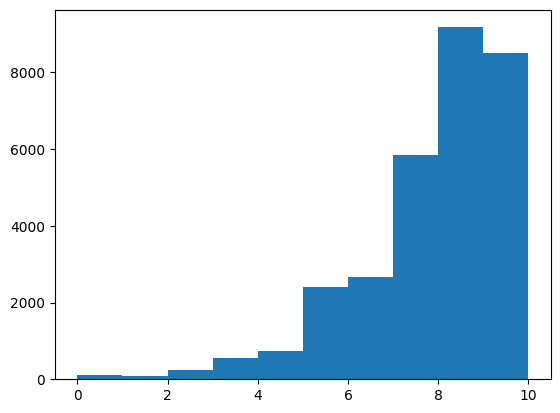

In [25]:
plt.hist(y_train, bins = 10)
None

# Большинство людей счастливы :)

In [26]:
import sklearn.metrics

feature_names = ohe.get_feature_names_out()

def analyze(model):
    model.fit(X_train, y_train) # Обучаем модель
    y_pred = model.predict(X_test) # Получаем предсказания
    print(model.alpha_)
    print(model.coef_)
    
    # Считаем метрики качества
    medae_test = sklearn.metrics.median_absolute_error(y_test, y_pred)
    medae_train = sklearn.metrics.median_absolute_error(y_train, model.predict(X_train))
    print({ "MedAE on training set": f"{medae_train:.2f}", "MedAE on testing set": f"{medae_test:.2f}" })
        
    # Смотрим на распределение ошибок
    sklearn.metrics.PredictionErrorDisplay.from_predictions(
        y_test, y_pred, kind = "actual_vs_predicted", scatter_kwargs = {"alpha": 0.5}
    )
    
    # Выводим отсортированные коэффициенты регрессии
    coefs = pandas.DataFrame(model.coef_, columns = ["Coefficients"], index = feature_names)
    coefs_sorted = coefs.sort_values(by = 'Coefficients', ascending = False)
    display(coefs_sorted.head(10))
    display(coefs_sorted.tail(10))

533.6699231206302
[ 8.11411506e-03 -9.08575047e-05 -1.23436776e-03  1.12799723e-02
 -1.18306289e-02 -3.00135546e-03 -3.41588628e-03 -9.01194176e-03
  7.94314496e-04 -9.90384088e-04 -6.45317191e-03 -1.89712427e-03
  7.87729814e-03 -1.46297370e-02 -1.77959787e-03 -8.62822693e-03
 -2.26505828e-03  1.53542096e-02 -8.36259311e-03 -7.12939598e-03
  9.06315576e-03  1.33911893e-02 -2.03695063e-03 -1.53722477e-03
  3.35885132e-02  1.11990941e-02  1.01151387e-02 -4.79881404e-03
 -2.50438726e-02 -9.82737560e-04 -9.62601598e-03  5.05260145e-03
 -8.83607024e-03 -6.97768255e-03 -2.26656270e-02  1.22645863e-03
  1.68981709e-02  7.15183409e-03  5.95972676e-04  2.18964978e-03
 -1.48938158e-03 -4.05681481e-03 -1.21581096e-03  1.04880408e-02
 -6.66364999e-03  3.82582059e-03 -6.90904024e-03 -1.88672373e-02
  2.25713782e-02  2.02533607e-02  3.21799019e-02 -5.17604852e-03
 -9.17252040e-03  2.71188837e-03  3.49727101e-03  4.74608959e-04
  4.25621095e-03  5.44342994e-04  2.68536993e-02  1.80803475e-02
 -1.450

,Coefficients
numeric__stflife,0.801908
numeric__ctrlife,0.198844
binary__pdwrkp,0.077928
numeric__femifel,0.077530
binary__rtrdp,0.066105
numeric__sclmeet,0.063510
numeric__atchctr,0.054339
categorical__cntry_LT,0.049505
numeric__likrisk,0.047516
numeric__atcherp,0.046389


,Coefficients
numeric__maritalb,-0.035538
numeric__ipgdtima,-0.038607
categorical__cntry_SE,-0.041309
numeric__flteeff,-0.043062
numeric__hincfel,-0.058501
categorical__cntry_BG,-0.085378
numeric__fltlnl,-0.100610
numeric__fltdpr,-0.109285
numeric__fltsd,-0.120323
numeric__health,-0.138645


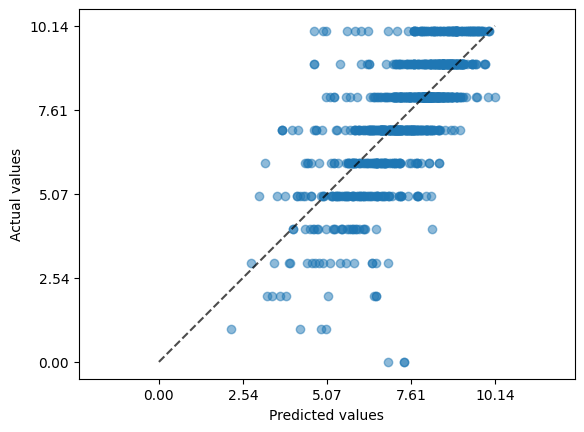

In [27]:
import sklearn.linear_model

analyze(sklearn.linear_model.RidgeCV(alphas = numpy.logspace(-10, 10, 100)))

- Коэффициенты выглядят нормально, переобучение не наблюдается.
- Качество в целом неплохое; модель в среднем ошибается на 0.64 единицы. Тем не менее ошибок достаточно много.
- Самый большой коэффициент - у признака "stflife": ответ на вопрос "All things considered, how satisfied are you with your life as a whole nowadays?". Это, в целом, ожидаемо: получается, в датасете два очень похожих по смыслу признака. Целесообразно убедиться в связи `stflife` и `happy`, после чего удалить первый из выборки.

0.6778082381021698


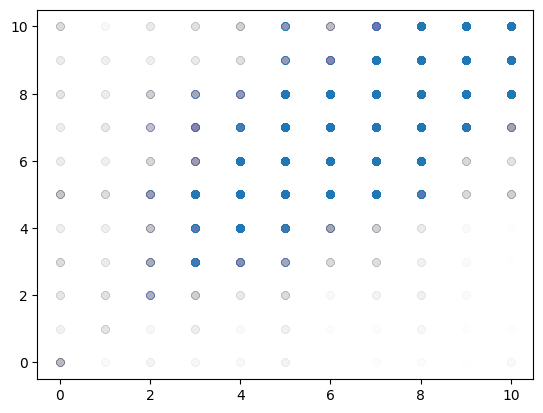

In [28]:
plt.scatter(data["stflife"], data["happy"], alpha = 0.005)
print(data["stflife"].corr(data["happy"]))

Хотя корелляция и не единица, связь удовлетворенности жизнью и счастья достаточна велика (хотя смысловая разница между этими признаками и не очень понятна). Удалим `stflife` из датасета.

In [29]:
X_train = X_train[:, ohe.get_feature_names_out() != 'numeric__stflife']
X_test = X_test[:, ohe.get_feature_names_out() != 'numeric__stflife']
feature_names = [ f for f in feature_names if f != 'numeric__stflife']

X_train.shape, X_test.shape, len(feature_names)

((30344, 235), (3372, 235), 235)

Повторим анализ.

1353.0477745798075
[ 1.71118566e-03 -3.97743181e-03 -5.50404936e-03  8.73052835e-03
 -1.73627031e-02 -1.15731331e-02 -4.47610830e-03 -1.63907641e-02
  3.53099153e-03  5.35845017e-04 -1.11746833e-02 -2.81394519e-03
  1.57018549e-02 -1.59652429e-02 -1.11777843e-02 -8.92521028e-03
 -1.40793812e-03  1.79703680e-02 -1.37664423e-02 -1.15514107e-02
  5.38730611e-03  4.23355588e-03 -3.18071304e-03 -4.47249997e-04
  3.34458940e-02  4.49424209e-03  8.77758942e-03 -2.20033661e-02
 -2.14511220e-02 -4.73181755e-03 -1.24155125e-02  1.06146055e-02
 -1.06455348e-02 -4.33942843e-03 -1.54820022e-02  1.56529484e-03
  1.74576503e-02  1.31440438e-02  4.90858316e-04  7.16031243e-03
 -3.81284945e-03 -1.19368922e-02  5.03487115e-03  2.29342929e-02
 -5.32373825e-03  5.80395278e-05 -3.21368588e-03 -1.92534023e-02
  2.24372074e-02  1.70965644e-02  3.86864919e-02 -1.08577525e-02
 -2.83185840e-03  9.42643377e-03  6.50217853e-03 -8.82229971e-03
  1.14098245e-03  2.36832560e-03  2.37390131e-02  2.53471199e-03
 -4.85

,Coefficients
numeric__ctrlife,0.342511
numeric__stfeco,0.147060
numeric__trstplc,0.100569
binary__pdwrkp,0.100507
numeric__sclmeet,0.097500
numeric__atchctr,0.085917
binary__rtrdp,0.081713
numeric__femifel,0.075052
numeric__actcomp,0.069150
numeric__stfhlth,0.064151


,Coefficients
numeric__ipcrtiva,-0.050099
categorical__cntry_IT,-0.052308
numeric__ipgdtima,-0.052856
numeric__flteeff,-0.053312
categorical__cntry_BG,-0.091276
numeric__hincfel,-0.147946
numeric__fltlnl,-0.149628
numeric__fltsd,-0.170126
numeric__fltdpr,-0.177892
numeric__health,-0.194702


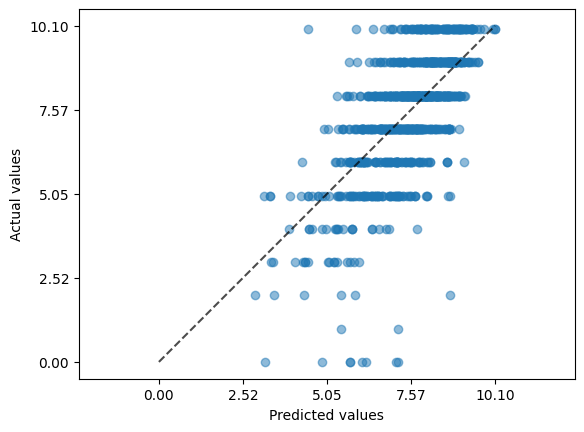

In [30]:
import sklearn.linear_model

analyze(sklearn.linear_model.RidgeCV(alphas = numpy.logspace(-10, 10, 100)))

Предсказания, очевидно, стали немного хуже: теперь модель ошибается в среднем на 0.75 "единиц счастья". Тем не менее общий тренд сохраняется, и коэффициенты пригодны для анализа.

Признаками с наибольшем положительным влиянием на счастье оказались:
- `ctrlife`: "How much control do you feel you have over your life in general nowadays?"
- `stfeco`: "On the whole how satisfied are you with the present state of the economy in [country]?"
- `trstplc`: "How much you personally trust the police?"
- `pdwrkp`: "Partner doing last 7 days: paid work"
- `sclmeet`: "How often do you meet socially with friends, relatives or work colleagues?"

Ожидаемо, контроль над собственной жизнью, хорошая экономика, доверие правоохранительным органам, встречи с друзьями повышают счастье людей. Тем не менее интересно, что оплачиваемая работа партнёра также является одним из ключевых факторов, повышающих счастье. Хотя это и является важным факторов благополучия, мне кажется неожиданным, что этот признак оказался среди 5 наиболее важных для общего уровня счастья, так как наличие работы имеет и свои "минусы": стресс, меньше времени с семьей

В свою очередь, отрицательно влияют признаки:
- `health`: "How is your health in general (1 - Very good; 5 - Very bad)?"
- `fltdpr`: "How much of the time during the past week you felt depressed?"
- `fltsd`: "How much of the time during the past week you felt sad?"
- `fltlnl`: "How much of the time during the past week you felt lonely?"
- `hincfel`: "Which of the descriptions on this card comes closest to how you feel about your household's income nowadays (1 - 	Living comfortably on present income; 4 - Very difficult on present income)?"

В части признаков, уменьшающих счастье, интересных закономерностей не обнаружено. Проблемы со здоровьем, депрессия, грусть, одиночество, низкий доход действительно понижают счастье.

Интересно, что страна проживания человека не оказалась среди влиятельных признаков.

0.0029836472402833404
[ 0.00000000e+00 -2.10928169e-05 -2.94562167e-03  2.71429849e-03
 -1.51800734e-02 -7.13831694e-03 -2.24584341e-03 -1.52714016e-02
  8.41824320e-04  0.00000000e+00 -3.98438868e-03 -0.00000000e+00
  1.29482385e-02 -1.16672199e-02 -7.02474898e-03 -6.85407252e-03
  0.00000000e+00  1.71995171e-02 -9.44838002e-03 -7.27382191e-03
  1.34498146e-03  1.02738839e-03 -0.00000000e+00  0.00000000e+00
  3.49360331e-02  6.82466208e-04  6.61244194e-03 -2.45353599e-02
 -9.47532134e-03 -0.00000000e+00 -7.65787675e-03  9.11793157e-03
 -1.42238309e-03  0.00000000e+00 -1.23338668e-02  7.67616169e-05
  1.58248780e-02  1.10281551e-02  0.00000000e+00  4.20986250e-03
 -0.00000000e+00 -7.22819421e-03  2.52113895e-03  2.28411583e-02
 -0.00000000e+00  0.00000000e+00 -0.00000000e+00 -1.21761460e-02
  1.84166298e-02  1.22517733e-02  3.83600431e-02 -5.47681751e-03
 -0.00000000e+00  7.17947796e-03  0.00000000e+00 -3.52281649e-03
  0.00000000e+00  0.00000000e+00  2.30693010e-02  0.00000000e+00
 -0

,Coefficients
numeric__ctrlife,0.357526
numeric__stfeco,0.151056
numeric__trstplc,0.102711
binary__pdwrkp,0.100353
numeric__sclmeet,0.098240
numeric__atchctr,0.084160
binary__rtrdp,0.082626
numeric__femifel,0.080404
numeric__actcomp,0.073785
numeric__likrisk,0.064846


,Coefficients
numeric__ipcrtiva,-0.049400
categorical__cntry_GR,-0.049553
numeric__ipgdtima,-0.051876
categorical__cntry_IT,-0.059754
categorical__cntry_BG,-0.095350
numeric__fltlnl,-0.153610
numeric__hincfel,-0.153816
numeric__fltsd,-0.174183
numeric__fltdpr,-0.181132
numeric__health,-0.205287


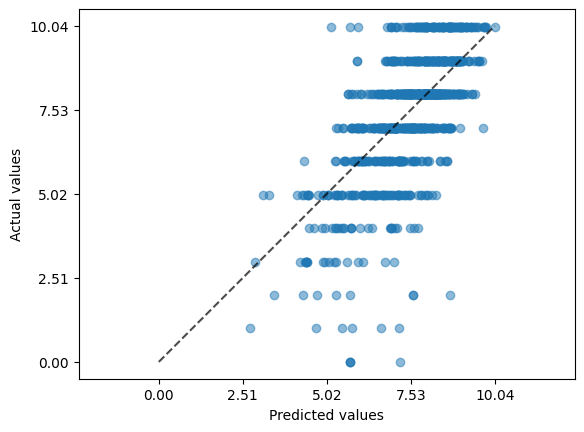

In [31]:
import sklearn.linear_model

numpy.random.seed(42)
analyze(sklearn.linear_model.LassoCV(alphas = numpy.logspace(-10, 10, 100), max_iter = 100000, n_jobs = -1))

Lasso-регрессия даёт схожие результаты, подтверждая стабильность полученных выводов

## Задача со звездочкой 11: NNLS (2 балла)
Напишите свою Non-Negative-Least-Squares на numpy **(scipy.optimize нельзя)**.

Подробно прокомментируйте, почему ваш алгоритм работает.

In [32]:
numpy.random.seed(42)

In [33]:
# Тестовые данные из https://scikit-learn.org/stable/auto_examples/linear_model/plot_nnls.html#sphx-glr-auto-examples-linear-model-plot-nnls-py

n_samples, n_features = 200, 50
X = numpy.random.randn(n_samples, n_features)
true_coef = 3 * numpy.random.randn(n_features)
# Threshold coefficients to render them non-negative
true_coef[true_coef < 0] = 0
y = numpy.dot(X, true_coef)

# Add some noise
y += 5 * numpy.random.normal(size=(n_samples,))

import sklearn.model_selection
X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(X, y, test_size=0.5)

In [34]:
# Базовая реализация из sklearn

import sklearn.metrics
import sklearn.linear_model

reg_nnls = sklearn.linear_model.LinearRegression(positive = True, fit_intercept = False)
y_pred_nnls = reg_nnls.fit(X_train, y_train).predict(X_test)
print(sklearn.metrics.r2_score(y_test, y_pred_nnls))
reg_nnls.coef_

0.8225967024090853


array([1.02322641, 0.        , 0.        , 0.        , 4.66024095,
       0.        , 2.63820007, 0.36137178, 0.66596945, 2.27794718,
       2.94142635, 1.80532376, 0.        , 0.42413976, 2.46643109,
       0.47224297, 0.        , 1.52179551, 0.06796534, 5.22312051,
       5.15989079, 1.9371303 , 3.8018638 , 0.51789773, 1.78100882,
       4.5722123 , 2.35630686, 0.72617371, 0.        , 0.59315682,
       2.32957486, 3.44255701, 1.5004018 , 0.        , 0.17106419,
       0.34540708, 0.15791368, 0.05010652, 0.87337103, 7.70309685,
       0.        , 0.        , 0.28231551, 0.        , 0.59877762,
       0.82813414, 0.73142642, 0.80178401, 0.        , 2.0370571 ])

Реализуем классический градиентный спуск, но по-координатно и с проекцией на $w_i \ge 0$.

Идея алгоритма: оптимизируем веса по-одному аналитически (решаем одномерную задачу оптимизации MSE), но если получился отрицательный вес, считаем его равным нулю. Таким образом, каждая итерация не ухудшает результат (изменяемый коэффициент либо станет лучше, либо не изменится), а проход по всем параметрам даёт убывание функции потерь в совокупности. Соответственно, при достаточном количестве итераций, алгоритм сойдется к некоторому минимуму по аналогии с обычным градиентным спуском, и веса перестанут обновляться.

Одномерная задача оптимзации MSE:
$$ MSE = ||Xw - y|| ^ 2 = w^T X^T X w - 2 w^T X^T y + y^T y $$
$$\dfrac{d(MSE)}{d(x_i)} = 2 \left( (X^T X)_{i, :} w - (X^T y)_{i} \right) = 0 $$
$$(X^T X)_{i, :} w = (X^T y)_{i}$$
$$(X^T X)_{i, i} w_i + \sum_{j \ne i} \left( (X^T X)_{i, j} w_j \right) = (X^T y)_{i}$$
$$w_i = \dfrac{(X^T y)_{i} - \sum_{j \ne i} \left( (X^T X)_{i, j} w_j \right)}{(X^T X)_{i, i}}$$
$$w_i := \dfrac{(X^T y)_{i} - (X^T X)_{i, :} w + (X^T X)_{i, i} w_i}{(X^T X)_{i, i}}$$

In [35]:
def nnls(X: numpy.ndarray, y: numpy.ndarray, iter: int = 5000):
    XtX = X.T @ X
    Xty = X.T @ y

    # Инициализируем веса
    w = numpy.zeros(X.shape[1])

    # Повторяем много раз, чтобы сошлось
    for _ in range(iter):

        # Проходим по каждой координате w
        for i in range(len(w)):
            # Одномерная оптимизация MSE
            w[i] = (Xty[i] - XtX[i, :] @ w + XtX[i, i] * w[i]) / XtX[i, i]

            # Если оптимальный w[i] получился отрицательным, берем 0
            w[i] = max(0.0, w[i])

    return w

In [36]:
W = nnls(X_train, y_train)
print(sklearn.metrics.r2_score(y_test, X_test @ W))
print(W)

0.8225967024090852
[1.02322641 0.         0.         0.         4.66024095 0.
 2.63820007 0.36137178 0.66596945 2.27794718 2.94142635 1.80532376
 0.         0.42413976 2.46643109 0.47224297 0.         1.52179551
 0.06796534 5.22312051 5.15989079 1.9371303  3.8018638  0.51789773
 1.78100882 4.5722123  2.35630686 0.72617371 0.         0.59315682
 2.32957486 3.44255701 1.5004018  0.         0.17106419 0.34540708
 0.15791368 0.05010652 0.87337103 7.70309685 0.         0.
 0.28231551 0.         0.59877762 0.82813414 0.73142642 0.80178401
 0.         2.0370571 ]


In [37]:
print(reg_nnls.coef_ - W) # Результаты близки к тому, что вывела готовая реализация из sklearn

[ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00 -1.33226763e-15  5.55111512e-16
  0.00000000e+00  0.00000000e+00  8.88178420e-16  4.44089210e-16
  0.00000000e+00 -6.66133815e-16  0.00000000e+00 -4.44089210e-16
  0.00000000e+00  8.88178420e-16 -1.42941214e-15 -1.77635684e-15
 -1.77635684e-15 -4.44089210e-16  0.00000000e+00 -5.55111512e-16
 -2.22044605e-16  8.88178420e-16  0.00000000e+00 -4.44089210e-16
  0.00000000e+00 -4.44089210e-16  0.00000000e+00 -1.77635684e-15
 -2.22044605e-16  0.00000000e+00 -5.27355937e-16  0.00000000e+00
 -2.49800181e-16 -2.15105711e-16  6.66133815e-16 -1.77635684e-15
  0.00000000e+00  0.00000000e+00 -6.66133815e-16  0.00000000e+00
 -4.44089210e-16  7.77156117e-16  3.33066907e-16 -1.11022302e-16
  0.00000000e+00  0.00000000e+00]


## Задача со звездочкой 12: ODR (4 балла)
Откройте [ODRPACK User Guide](https://docs.scipy.org/doc/external/odrpack_guide.pdf) (осторожно: FORTRAN-77), и разберитесь что происходит в этом примере, поищите более современные данные и воспроизведите.

Iteration: 0, Loss: 35.15132171696014
Iteration: 1, Loss: 25.973898018793324
Iteration: 2, Loss: 23.24802092872004
Iteration: 3, Loss: 22.242233902208273
Iteration: 4, Loss: 21.80455986435579
Iteration: 5, Loss: 21.608655969337775
Iteration: 6, Loss: 21.519987709667873
Iteration: 7, Loss: 21.47961110551041
Iteration: 8, Loss: 21.461153302970946
Iteration: 9, Loss: 21.452693561540364
Iteration: 10, Loss: 21.44880941425565
Iteration: 11, Loss: 21.447023952028346
Iteration: 12, Loss: 21.446202549308367
Iteration: 13, Loss: 21.445824455508518
Iteration: 14, Loss: 21.44565035319994
Iteration: 15, Loss: 21.44557016339038
Iteration: 16, Loss: 21.445533222419744
Iteration: 17, Loss: 21.44551620287461
Iteration: 18, Loss: 21.445508360963128
Iteration: 19, Loss: 21.44550474753652
Iteration: 20, Loss: 21.445503082468043
Iteration: 21, Loss: 21.445502315183248
Iteration: 22, Loss: 21.445501961603323
Iteration: 23, Loss: 21.445501798664637
Iteration: 24, Loss: 21.44550172357952
Iteration: 25, Loss:

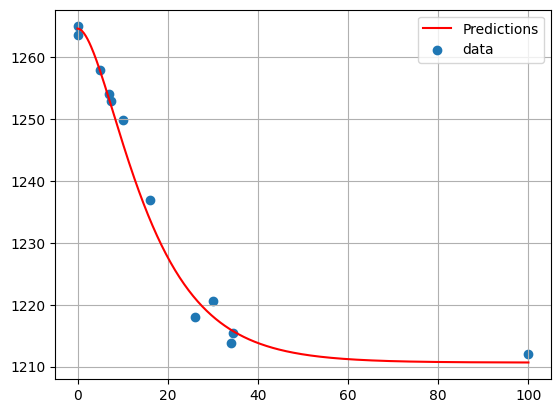

In [38]:
# Будем воспроизводить пример "2.C.i. Example Problem for an Explicit Model"

# c Compute predicted values
#     IF (MOD(ideval,10).GE.1) THEN
#       DO 110 l = 1,nq
#         DO 100 i = 1,n
#           f(i,l) = beta(1) +
#    +               beta(2)*(exp(beta(3)*xplusd(i,1)) - 1.0d0)**2
# 100     CONTINUE
# 110   CONTINUE
#     END IF
def f(beta, xplusd):
    return beta[0] + beta[1] * (numpy.exp(beta[2] * xplusd) - 1.0) ** 2

# c Compute derivatives with respect to beta
#     IF (MOD(ideval/10,10).GE.1) THEN
#       DO 210 l = 1,nq
#         DO 200 i = 1,n
#           fjacb(i,1,l) = 1.0d0
#           fjacb(i,2,l) = (exp(beta(3)*xplusd(i,1)) - 1.0d0)**2
#           fjacb(i,3,l) = beta(2)*2*
#    +                     (exp(beta(3)*xplusd(i,1)) - 1.0d0)*
#    +                     exp(beta(3)*xplusd(i,1))*xplusd(i,1)
# 200     CONTINUE
# 210   CONTINUE
#     END IF
def fjacb(beta, xplusd):
    # fjacb(i,1,l) = 1.0d0
    fjacb1 = numpy.ones_like(xplusd)

    # fjacb(i,2,l) = (exp(beta(3)*xplusd(i,1)) - 1.0d0)**2
    fjacb_2 = (numpy.exp(beta[2] * xplusd) - 1.0) ** 2
    
    # fjacb(i,3,l) = beta(2)*2*
    #                (exp(beta(3)*xplusd(i,1)) - 1.0d0)*
    #                exp(beta(3)*xplusd(i,1))*xplusd(i,1)
    fjacb_3 = (beta[1] * 2.0 *
              (numpy.exp(beta[2] * xplusd) - 1.0) *
              numpy.exp(beta[2] * xplusd) * xplusd)
    
    return numpy.column_stack([ fjacb1, fjacb_2, fjacb_3 ])

# c Compute derivatives with respect to delta
#     IF (MOD(ideval/100,10).GE.1) THEN
#       DO 310 l = 1,nq
#         DO 300 i = 1,n
#           fjacd(i,1,l) = beta(2)*2*
#     +                    (exp(beta(3)*xplusd(i,1)) - 1.0d0)*
#     +                    exp(beta(3)*xplusd(i,1))*beta(3)
# 300     CONTINUE
# 310   CONTINUE
#     END IF
def fjacd(beta, xplusd):
    return (beta[1] * 2.0 *
            (numpy.exp(beta[2] * xplusd) - 1.0) *
            numpy.exp(beta[2] * xplusd) * beta[2])


# c Compute solution
#     CALL dodrc(fcn,
#    +           n,m,np,nq,
#    +           beta,
#    +           y,ldy,x,ldx,
#    +           we,ldwe,ld2we,wd,ldwd,ld2wd,
#    +           ifixb,ifixx,ldifx,
#    +           job,ndigit,taufac,
#    +           sstol,partol,maxit,
#    +           iprint,lunerr,lunrpt,
#    +           stpb,stpd,ldstpd,
#    +           sclb,scld,ldscld,
#    +           work,lwork,iwork,liwork,
#    +           info)
#     END
def dodrc(
    x: numpy.ndarray, y: numpy.ndarray, beta: numpy.ndarray, ifixx: numpy.ndarray,
    # --- stopping criteria:
    #     sstol = 1.49D-08 (sum of squares stopping tolerance)
    #     partol = 3.67D-11 (parameter stopping tolerance)
    #     maxit = 50 (maximum number of iterations)
    sstol: float = 1.49e-8, partol: float = 3.67e-11, max_iter: int = 50
):
    # Конкретная реализация функции dodrc в User Guide не приведена,
    # поэтому делаем свою по текстовому описанию из секции "1.B. Algorithm"

    # Минимизируем (x - x_adj) ^ 2 + (y - f) ^ 2 в два действия:
    # - Для фиксированного x_adj обновляем веса beta по МНК
    # - Для фиксированных весов beta делаем шаг Гаусса-Ньютона для обновления x_adj

    def loss(x_adj, beta):
        return numpy.sum((x - x_adj) ** 2 + (y - f(beta, x_adj)) ** 2)

    x_adj = x.copy()
    for num_iter in range(max_iter):
        beta_old = beta.copy()
        x_adj_old = x_adj.copy()

        # Шаг по beta
        J = fjacb(beta, x_adj)
        # Обновляем веса из решения уравнения (J^T * J) * delta(beta) = J^T * (y - f)
        # Почти как в обычной линейной регрессии: beta := beta + (J^T * J) ^ (-1) * J^T * (y - f)
        beta += numpy.linalg.inv(J.T @ J) @ J.T @ (y - f(beta, x_adj))

        # Шаг по x
        # g(x) = (x - x_adj) ^ 2 + (y - f) ^ 2
        # g'(x) = 2 * (x - x_adj) + 2 * (y - f) * df/dx
        # g''(x) = 2 + 2 * (df/dx) ^ 2
        J = fjacd(beta, x_adj)
        g1 = 2 * (x - x_adj) + 2 * (y - f(beta, x_adj)) * J
        g2 = 2 + 2 * (J ** 2)
        x_adj[~ifixx] += (g1 / g2)[~ifixx]

        print(f"Iteration: {num_iter}, Loss: {loss(x_adj, beta)}")

        # Наконец, критерии остановки. Из User Guide:
        # The iterations are stopped when any one of three stopping criteria are met.
        
        # The weighted sum of the squared observation errors is sufficiently small
        if loss(x_adj, beta) < sstol:
            print('Stopped by sum of the squared observation errors')
            return beta
        
        # The change in the estimated values of beta and x_adj is sufficiently small.
        beta_diff = (beta - beta_old).sum() ** 2
        x_adj_diff = (x_adj - x_adj_old).sum() ** 2
        if beta_diff < partol and x_adj_diff < partol:
            print('Stopped by small parameter change')
            return beta

        # The third stopping criterion is a limit on the number of iterations.

    print('Stopped by iteration limit')
    return beta

# Раздел "2.C.i.b. User Supplied Data (file data1)"
x = numpy.array([ 0.0, 0.0, 5.0, 7.0, 7.5, 10.0, 16.0, 26.0, 30.0, 34.0, 34.5, 100.0 ])
y = numpy.array([ 1265.0, 1263.6, 1258.0, 1254.0, 1253.0, 1249.8, 1237.0, 1218.0, 1220.6, 1213.8, 1215.5, 1212.0 ])
beta = numpy.array([ 1500.0, -50.0, -0.1 ])

# if (x(i,1).eq.0.0d0 .or. x(i,1).eq.100.0d0) then
#   ifixx(i,1) = 0
# else
#   ifixx(i,1) = 1
# end if
ifixx = (x == 0.0) | (x == 100.0)

beta = dodrc(x, y, beta, ifixx)
print("Beta estimates: ", beta)

x_grid = numpy.linspace(x.min(), x.max(), 500)
plt.plot(x_grid, f(beta, x_grid), "r", label = "Predictions")
plt.scatter(x, y, label = "data")
plt.legend()
plt.grid()

В User Guide:
- "--- final weighted sums of squares = 2.14455017D+01"
- --- estimated beta(j), j = 1, ..., np:
    -  1.26465481D+03
    -  -5.40184100D+01
    - -8.78497122D-02

Получилось:
- Сумма квадратов ошибок: `21.445501659430064`
- Оценки параметров:
    - `1.26465481e+03`
    - `-5.40183900e+01`
    - `-8.78498362e-02`

Все результаты достаточно близки.